In [1]:
import pandas as pd
import pickle
import torch
from torch.utils.data import DataLoader, Subset
import os
import numpy as np
import sys
# Aggiunge la cartella src al path
sys.path.append(os.path.abspath('../src'))
# Ora puoi importare normalmente
from data_class import Nuc_Dataset
#from utils import training_and_validation_loop_classification, collate_fn,test_classification,training_validation_and_test_loop_classification,find_best_threshold
from utils import test_classification,training_validation_and_test_loop_classification


from model import CadmusDNA,TransformerNuc_Cadmus
from collections import Counter

from sklearn.model_selection import StratifiedKFold, train_test_split
import math
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict
from Bio.Seq import Seq
import random

In [2]:
#CARICAMENTO DATI

In [3]:
###
RC_augmentation = True

#Train dataset

with open('../data/data_pkl/Lymphoblastoid_99_8_percentile.pkl', 'rb') as f:   
    dataset_sapiens_lymphoblastoid = pickle.load(f)

if RC_augmentation:
    for d1, d2 in zip(dataset_sapiens_lymphoblastoid, dataset_sapiens_lymphoblastoid):
        d1['sequence_rev'] = str(Seq(d1['sequence']).reverse_complement())

#test dataset act

with open('../data/data_pkl/CD4T_h19_Act_tot_99_8_percentile.pkl', 'rb') as f:   
    dataset_sapiens_cd4t_act = pickle.load(f)
if RC_augmentation:
    for d1, d2 in zip(dataset_sapiens_cd4t_act, dataset_sapiens_cd4t_act):
        d1['sequence_rev'] = str(Seq(d1['sequence']).reverse_complement())


with open('../data/data_pkl/CD4T_h19_Rest_tot_99_8_percentile.pkl', 'rb') as f:   
    dataset_sapiens_cd4t_rest = pickle.load(f)
if RC_augmentation:
    for d1, d2 in zip(dataset_sapiens_cd4t_rest, dataset_sapiens_cd4t_rest):
        d1['sequence_rev'] = str(Seq(d1['sequence']).reverse_complement())



len(dataset_sapiens_lymphoblastoid)

194716

In [4]:
def set_seed(seed=42):
    random.seed(seed)                          # Seed Python (modulo random)
    np.random.seed(seed)                       # Seed NumPy
    torch.manual_seed(seed)                    # Seed PyTorch CPU
    torch.cuda.manual_seed(seed)               # Seed PyTorch CUDA (una GPU)
    torch.cuda.manual_seed_all(seed)           # Seed PyTorch CUDA (tutte le GPU)

    torch.backends.cudnn.deterministic = True  # Usa algoritmi deterministici
    torch.backends.cudnn.benchmark = False     # Disabilita ottimizzazioni non deterministiche

    print(f"Seeds fixed with seed = {seed}")
set_seed()

Seeds fixed with seed = 42


In [5]:
#conto le occorrenze per ogni classe
labels = [entry['label'] for entry in dataset_sapiens_lymphoblastoid]
label_counts = Counter(labels)
for label, count in label_counts.items():
    print(f"Label {label}: {count} samples")


Label 1: 97358 samples
Label 0: 97358 samples


In [6]:
#conto le occorrenze per ogni classe
labels = [entry['label'] for entry in dataset_sapiens_cd4t_rest]
label_counts = Counter(labels)
for label, count in label_counts.items():
    print(f"Label {label}: {count} samples")


Label 1: 58489 samples
Label 0: 58489 samples


In [7]:
# best_hyperparameters = {'dropout_rate': 0.3143462158665756,
#  'num_heads': 8,
#  'batch_size': 32,
#  'lr': 1.4271180164633878e-06,
#  'weight_decay': 1.2306663346888495e-06,
#  'patience': 12}

In [8]:
best_hyperparameters = {'dropout_rate': 0.3832290311184182, 'num_heads': 5,
                       'batch_size': 32, 'lr': 2.3270677083837795e-06,
                       'weight_decay': 8.179499475211672e-08, 'patience': 10}

In [9]:

# #CV WITH EARLY STOPPING

from sklearn.metrics import confusion_matrix, accuracy_score, matthews_corrcoef, roc_auc_score
import numpy as np

def classification_metrics(y_true, probs_pred, threshold=0.5):
    """
    Calcola Sensitivity, Specificity, Accuracy, MCC e AUC
    a partire da y_true (etichette vere) e probs_pred (probabilità predette).
    
    Parametri:
        y_true: array-like di etichette vere (0 o 1)
        probs_pred: array-like di probabilità predette (float tra 0 e 1)
        threshold: soglia di classificazione (default 0.5)
    
    Ritorna:
        dizionario con le metriche richieste
    """
    # Conversione in predizioni binarie
    y_pred = (np.array(probs_pred) >= threshold).astype(int)
    y_true = np.array(y_true)
    
    # Matrice di confusione
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    # Metriche
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    accuracy = accuracy_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    auc = roc_auc_score(y_true, probs_pred)
    
    return {
        "Sensitivity_val": sensitivity,
        "Specificity_val": specificity,
        "Accuracy_val": accuracy,
        "MCC_val": mcc,
        "AUC_val": auc
    }

    

g = torch.Generator()
g.manual_seed(0) # Usa lo stesso seed

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

dim_embedding = 2560#1280#2560
# data = [x for x in data if x['embedding'].shape[0] == 37]#[:3000] 

dataset_train = Nuc_Dataset(dataset_sapiens_lymphoblastoid,max_length=37, rc_augmentation=True)# dim_embedding, drop_last=False)
dataset_test_act = Nuc_Dataset(dataset_sapiens_cd4t_act,max_length=37, rc_augmentation=True)# dim_embedding, drop_last=False)
dataset_test_rest = Nuc_Dataset(dataset_sapiens_cd4t_rest,max_length=37, rc_augmentation=True)# dim_embedding, drop_last=False)

dataloader_train = DataLoader(dataset_train, batch_size=32, shuffle=True, worker_init_fn=seed_worker, generator=g, drop_last=False )
dataloader_test_act = DataLoader(dataset_test_act, batch_size=32, shuffle=False, worker_init_fn=seed_worker, generator=g, drop_last=False )
dataloader_test_rest = DataLoader(dataset_test_rest, batch_size=32, shuffle=False, worker_init_fn=seed_worker, generator=g, drop_last=False )

transf_parameters_att = {'input_dim': dim_embedding, 
                         'dropout_rate': best_hyperparameters['dropout_rate'], 
                         'num_heads': best_hyperparameters['num_heads']}   



In [10]:
fold=0

In [11]:
# === RICARICA ===
best_model = CadmusDNA(TransformerNuc_Cadmus, transf_parameters_att, device)
state_dict =  torch.load(f"best_model_weights_99_8_percentile_fold{fold}_03_03_26.pt", map_location=device)# torch.load("best_model_weights_99_8_percentile_fold4.pt", map_location=device)
best_model.load_state_dict(state_dict)
best_model.to(device)
best_model.eval()



Using device: cuda


2026-02-19 15:56:29.507660: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-19 15:56:29.528746: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-19 15:56:29.528765: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-19 15:56:29.529651: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-19 15:56:29.533936: I tensorflow/core/platform/cpu_feature_guar

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Some weights of EsmModel were not initialized from the model checkpoint at InstaDeepAI/nucleotide-transformer-2.5B-multi-species and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


CadmusDNA(
  (model_LLM): EsmModel(
    (embeddings): EsmEmbeddings(
      (word_embeddings): Embedding(4105, 2560, padding_idx=1)
      (dropout): Dropout(p=0.0, inplace=False)
      (position_embeddings): Embedding(1002, 2560, padding_idx=1)
    )
    (encoder): EsmEncoder(
      (layer): ModuleList(
        (0-31): 32 x EsmLayer(
          (attention): EsmAttention(
            (self): EsmSelfAttention(
              (query): Linear(in_features=2560, out_features=2560, bias=True)
              (key): Linear(in_features=2560, out_features=2560, bias=True)
              (value): Linear(in_features=2560, out_features=2560, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): EsmSelfOutput(
              (dense): Linear(in_features=2560, out_features=2560, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (LayerNorm): LayerNorm((2560,), eps=1e-12, elementwise_affine=True)
          )
          (in

In [12]:
assert False

AssertionError: 

In [ ]:
###################################################################################
###################################################################################

Calibrazione della soglia ottimale...
 Calibration Complete. Best F1: 0.7493 @ Threshold: 0.0189
Ricerca esempi usando Threshold > 0.0189...
Trovato TN (Prob: 0.0119)
Trovato TP (Prob: 0.7162)

--- Plotting NUCLEOSOME (TP) ---


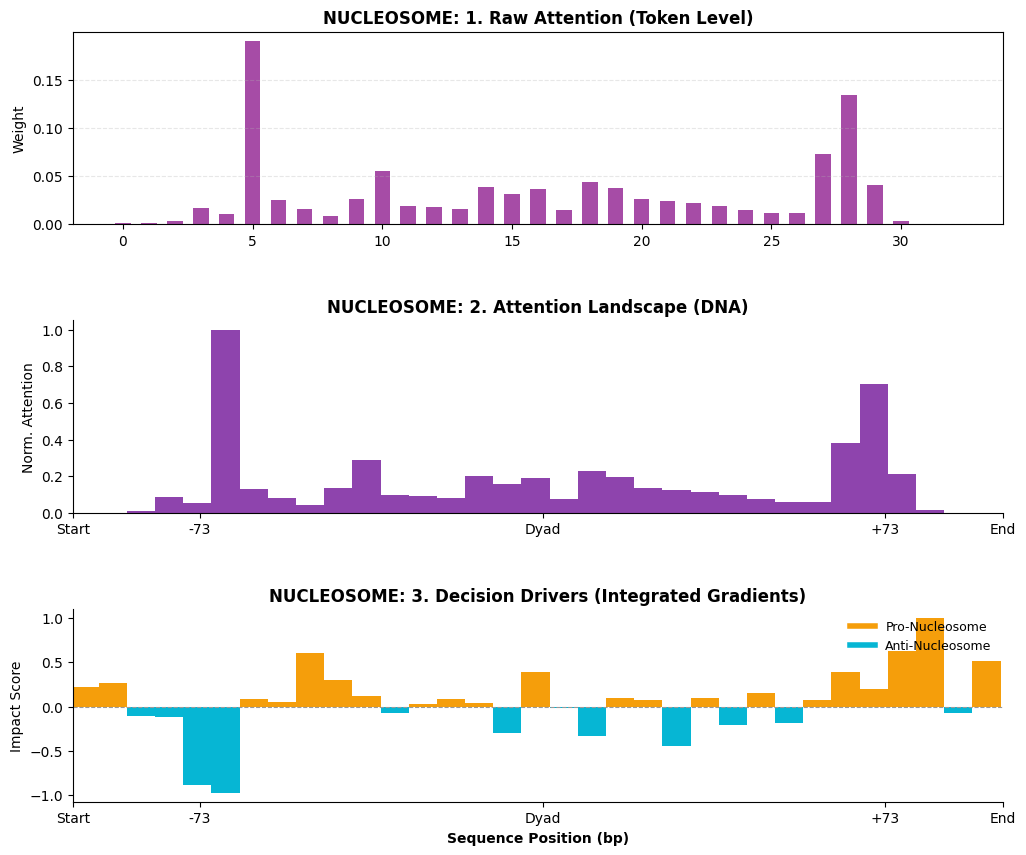


--- Plotting NON-NUCLEOSOME (TN) ---


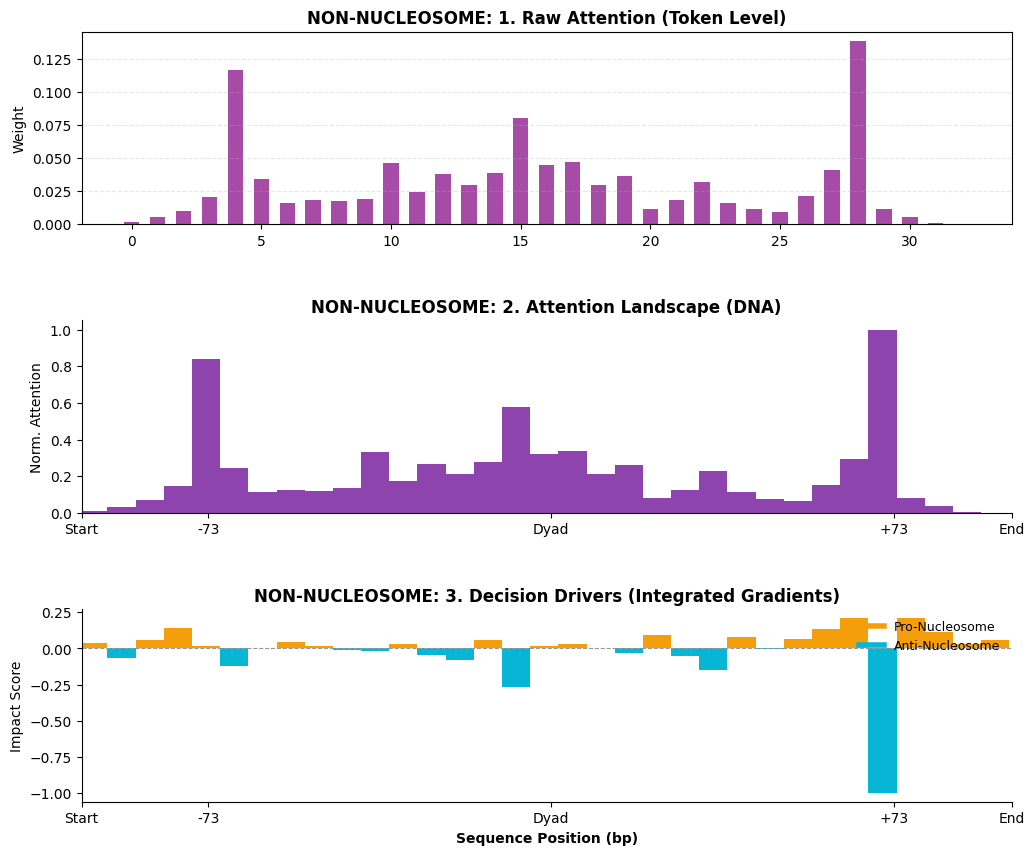

In [20]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from captum.attr import LayerIntegratedGradients
from matplotlib.lines import Line2D
from sklearn.metrics import precision_recall_curve
import warnings

# Ignora warning di sklearn/numpy per pulizia
warnings.filterwarnings('ignore')

# --- 1. CLASSI E FUNZIONI DI SUPPORTO ---

class InterpretableCadmus(torch.nn.Module):
    def __init__(self, original_model):
        super().__init__()
        self.model_LLM = original_model.model_LLM
        self.attention_model = original_model.attention_model
        
    def forward(self, input_ids, attention_mask):
        outputs = self.model_LLM(input_ids=input_ids, attention_mask=attention_mask)
        embedding_tot = outputs.last_hidden_state
        output_att, _ = self.attention_model(embedding_tot)
        return output_att.view(-1, 1)

def get_cls_attention(model, input_ids, attention_mask):
    model.eval()
    with torch.no_grad():
        outputs = model.model_LLM(input_ids=input_ids, attention_mask=attention_mask)
        _, attn_matrix = model.attention_model(outputs.last_hidden_state)
    if attn_matrix.dim() == 4: attn_avg = attn_matrix.mean(dim=1)
    else: attn_avg = attn_matrix
    return attn_avg[0, 0, :].cpu().numpy()

def expand_to_bp(tokens):
    expanded = []
    for t in tokens: expanded.extend([t] * 6)
    return np.array(expanded)

# --- 2. INIZIALIZZAZIONE ---

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
best_model.to(device)
best_model.eval()

# Wrapper Captum
interpretable_model = InterpretableCadmus(best_model).to(device)
lig = LayerIntegratedGradients(interpretable_model, interpretable_model.model_LLM.embeddings.word_embeddings)

# --- 3. CALIBRAZIONE SOGLIA (Nuova Sezione) ---

def calibrate_threshold(model, dataloader, device, max_batches=1000):
    """
    Trova la soglia che massimizza l'F1-Score su un subset del dataset.
    """
    print("Calibrazione della soglia ottimale...")
    y_true = []
    y_scores = []
    
    with torch.no_grad():
        for i, batch in enumerate(dataloader):
            if i >= max_batches: break # Limitiamo per velocità
            
            if isinstance(batch, dict):
                input_ids, mask, labels = batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['label'].to(device)
            else:
                input_ids, mask, labels = batch[0].to(device), batch[1].to(device), batch[2].to(device)
            
            logits = model(input_ids, mask)
            probs = torch.sigmoid(logits).squeeze()
            
            y_scores.extend(probs.cpu().numpy())
            y_true.extend(labels.cpu().numpy())
    
    y_true = np.array(y_true)
    y_scores = np.array(y_scores)
    
    # Calcolo curve precision-recall
    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
    
    # Calcolo F1 per ogni soglia
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
    
    # Trova indice del miglior F1
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]
    
    print(f" Calibration Complete. Best F1: {best_f1:.4f} @ Threshold: {best_threshold:.4f}")
    return best_threshold


DATALOADER= DataLoader(dataset_test_act, batch_size=32, shuffle=True, worker_init_fn=seed_worker, generator=g, drop_last=False )


# Eseguiamo la calibrazione
optimal_threshold = calibrate_threshold(interpretable_model, DATALOADER, device)

# --- 4. RICERCA ESEMPI CON SOGLIA CALIBRATA ---

print(f"Ricerca esempi usando Threshold > {optimal_threshold:.4f}...")
iter_loader = iter(DATALOADER)
found_tp, found_tn = False, False
batch_tp, batch_tn = None, None

while not (found_tp and found_tn):
    try:
        batch = next(iter_loader)
    except StopIteration:
        print("Dataset terminato.")
        break
        
    if isinstance(batch, dict):
        input_ids, mask, labels = batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['label'].to(device)
    else:
        input_ids, mask, labels = batch[0].to(device), batch[1].to(device), batch[2].to(device)
    
    with torch.no_grad():
        logits = interpretable_model(input_ids, mask)
        probs = torch.sigmoid(logits).squeeze()
        # Usiamo la soglia calibrata per decidere la classe predetta
        preds = (probs > optimal_threshold).float()
    
    # Cerca True Positive (Label=1, Pred=1)
    if not found_tp:
        # Nota: assicurati che probs e labels abbiano shape compatibili
        matches = ((labels == 1) & (preds == 1)).nonzero(as_tuple=True)[0]
        if len(matches) > 0:
            idx = matches[0].item()
            # Controllo extra: prendiamo un esempio "sicuro" (ben sopra la soglia)
            if probs[idx] > (optimal_threshold+0.6):
                batch_tp = (input_ids[idx].unsqueeze(0), mask[idx].unsqueeze(0))
                found_tp = True
                print(f"Trovato TP (Prob: {probs[idx]:.4f})")

    # Cerca True Negative (Label=0, Pred=0)
    if not found_tn:
        matches = ((labels == 0) & (preds == 0)).nonzero(as_tuple=True)[0]
        if len(matches) > 0:
            idx = matches[0].item()
            # Controllo extra: prendiamo un esempio "sicuro" (ben sotto la soglia)
            if probs[idx] < (optimal_threshold):
                batch_tn = (input_ids[idx].unsqueeze(0), mask[idx].unsqueeze(0))
                found_tn = True
                print(f"Trovato TN (Prob: {probs[idx]:.4f})")

# --- 5. FUNZIONE PLOT ---

def analyze_and_plot(input_tensor, mask_tensor, title_prefix):
    # Calcoli Captum
    attributions, _ = lig.attribute(
        inputs=input_tensor, additional_forward_args=(mask_tensor,),
        target=0, return_convergence_delta=True, n_steps=50, internal_batch_size=4
    )
    captum_raw = attributions.sum(dim=-1).squeeze(0).detach().cpu().numpy()
    attn_raw = get_cls_attention(best_model, input_tensor, mask_tensor)
    
    # Preparazione
    captum_valid = captum_raw[1:-3]
    attn_valid = attn_raw[1:-3]
    captum_bp = expand_to_bp(captum_valid)
    attn_bp = expand_to_bp(attn_valid)
    
    # Normalizzazione
    captum_bp = captum_bp / (np.max(np.abs(captum_bp)) + 1e-9)
    attn_bp = (attn_bp - attn_bp.min()) / (attn_bp.max() - attn_bp.min() + 1e-9)
    seq_len = len(captum_bp)
    
    # Plot
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False)
    plt.subplots_adjust(hspace=0.5)
    
    # 1. Token Attention
    axes[0].bar(range(len(attn_valid)), attn_valid, color='purple', alpha=0.7, width=0.6)
    axes[0].set_title(f"{title_prefix}: 1. Raw Attention (Token Level)", fontweight='bold')
    axes[0].set_ylabel("Weight")
    axes[0].grid(axis='y', ls='--', alpha=0.3)
    
    # 2. BP Attention
    axes[1].bar(range(len(attn_bp)), attn_bp, color='#8E44AD', width=1.0, edgecolor='none')
    axes[1].set_title(f"{title_prefix}: 2. Attention Landscape (DNA)", fontweight='bold')
    axes[1].set_ylabel("Norm. Attention")
    axes[1].set_xlim(0, seq_len)
    
    # 3. Importance
    colors = ['#F59E0B' if x > 0 else '#06B6D4' for x in captum_bp]
    axes[2].bar(range(len(captum_bp)), captum_bp, color=colors, width=1.0, edgecolor='none')
    axes[2].axhline(0, color='#999', lw=0.8, ls='--')
    axes[2].set_title(f"{title_prefix}: 3. Decision Drivers (Integrated Gradients)", fontweight='bold')
    axes[2].set_ylabel("Impact Score")
    axes[2].set_xlabel("Sequence Position (bp)", fontweight='bold')
    axes[2].set_xlim(0, seq_len)
    
    # Legend
    legend_elements = [
        Line2D([0], [0], color='#F59E0B', lw=4, label='Pro-Nucleosome'),
        Line2D([0], [0], color='#06B6D4', lw=4, label='Anti-Nucleosome')
    ]
    axes[2].legend(handles=legend_elements, loc='upper right', frameon=False, fontsize=9)
    
    # Ticks
    dyad = 100
    ticks = [0, dyad-73, dyad, dyad+73, seq_len]
    labels = ['Start', '-73', 'Dyad', '+73', 'End']
    valid = [i for i, t in enumerate(ticks) if t <= seq_len]
    for ax in axes[1:]:
        ax.set_xticks([ticks[i] for i in valid])
        ax.set_xticklabels([labels[i] for i in valid])
        sns.despine(ax=ax)
    
    plt.show()

# Esecuzione Finale
if found_tp:
    print("\n--- Plotting NUCLEOSOME (TP) ---")
    analyze_and_plot(batch_tp[0], batch_tp[1], "NUCLEOSOME")
else: print("Nessun TP trovato.")

if found_tn:
    print("\n--- Plotting NON-NUCLEOSOME (TN) ---")
    analyze_and_plot(batch_tn[0], batch_tn[1], "NON-NUCLEOSOME")
else: print("Nessun TN trovato.")

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from captum.attr import LayerIntegratedGradients
from tqdm import tqdm
import seaborn as sns
from matplotlib.lines import Line2D

# --- 1. SETUP ---
class InterpretableCadmus(torch.nn.Module):
    def __init__(self, original_model):
        super().__init__()
        self.model_LLM = original_model.model_LLM
        self.attention_model = original_model.attention_model
    def forward(self, input_ids, attention_mask):
        outputs = self.model_LLM(input_ids=input_ids, attention_mask=attention_mask)
        logit, _ = self.attention_model(outputs.last_hidden_state) 
        return logit.view(-1, 1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
best_model.to(device)
best_model.eval()

interpretable_model = InterpretableCadmus(best_model).to(device)
lig = LayerIntegratedGradients(interpretable_model, interpretable_model.model_LLM.embeddings.word_embeddings)

# --- 2. CALCOLO GLOBALE CON FLIP (Corretto) ---

def compute_global_importance_aligned(dataloader, max_batches=None):
    print("Inizio calcolo Global Importance (Allineamento Fwd + RC-Flipped)...")
    
    # 1. Determiniamo la lunghezza valida dei token (senza CLS e senza coda)
    # Nel tuo caso: 37 totali - 1 (CLS) - 3 (Padding) = 33 token validi
    # Modifica questi indici se la tua tokenizzazione è diversa
    START_IDX = 1
    END_IDX = -3
    
    # Accumulatore dinamico (verrà inizializzato al primo batch)
    global_sum = None
    total_samples = 0
    
    iterator = iter(dataloader)
    if max_batches is None: max_batches = len(dataloader)
    
    for i in tqdm(range(max_batches), desc="Processing Batches"):
        try:
            batch = next(iterator)
        except StopIteration:
            break
            
        # Gestione input
        if isinstance(batch, dict):
            input_ids_fwd = batch['input_ids'].to(device)
            mask_fwd = batch['attention_mask'].to(device)
            if 'input_ids_rc' in batch:
                input_ids_rc = batch['input_ids_rc'].to(device)
                mask_rc = batch['attention_mask_rc'].to(device)
            else:
                input_ids_rc = None
        else:
            # Fallback tuple
            input_ids_fwd, mask_fwd = batch[0].to(device), batch[1].to(device)
            input_ids_rc = batch[3].to(device) if len(batch) > 3 else None

        current_batch_size = input_ids_fwd.size(0)
        
        # --- A. CALCOLO IG FORWARD ---
        attr_fwd, _ = lig.attribute(
            inputs=input_ids_fwd, additional_forward_args=(mask_fwd,),
            target=0, n_steps=20, internal_batch_size=4, return_convergence_delta=True
        )
        # Somma su embedding (shape: [Batch, Seq_Len])
        scores_fwd = attr_fwd.sum(dim=-1)
        
        # TAGLIO I TOKEN: Teniamo solo la parte centrale valida
        valid_fwd = scores_fwd[:, START_IDX:END_IDX] # [Batch, 33]
        
        # --- B. CALCOLO IG RC (con FLIP) ---
        valid_rc = 0
        if input_ids_rc is not None:
            attr_rc, _ = lig.attribute(
                inputs=input_ids_rc, additional_forward_args=(mask_rc,),
                target=0, n_steps=20, internal_batch_size=4, return_convergence_delta=True
            )
            scores_rc = attr_rc.sum(dim=-1)
            
            # 1. Taglio anche l'RC (tolgo CLS e Pad)
            clean_rc = scores_rc[:, START_IDX:END_IDX] # [Batch, 33]
            
            # 2. FLIP GEOMETRICO: Ribaltiamo l'asse della sequenza (dimensione 1)
            # Ora l'inizio dell'array corrisponde fisicamente all'inizio del Fwd
            valid_rc = torch.flip(clean_rc, dims=[1]) 

        # --- C. SOMMA E ACCUMULO ---
        # Sommiamo per ogni esempio nel batch
        batch_combined = valid_fwd + valid_rc # [Batch, 33]
        
        # Sommiamo tutti gli esempi del batch in un unico vettore
        batch_total = batch_combined.sum(dim=0) # [33]
        
        # Inizializza accumulatore globale se vuoto
        if global_sum is None:
            global_sum = torch.zeros_like(batch_total)
            
        global_sum += batch_total
        total_samples += current_batch_size
        
    global_avg = global_sum / total_samples
    return global_avg.detach().cpu().numpy()

# ESECUZIONE

DATALOADER= DataLoader(dataset_train, batch_size=32, shuffle=True, worker_init_fn=seed_worker, generator=g, drop_last=False )

avg_token_scores = compute_global_importance_aligned(DATALOADER, max_batches=50)
print(f"Calcolo completato. Lunghezza token validi: {len(avg_token_scores)}")

# --- 3. MAPPING E PLOT ---

# A. Espansione a Basi (1 token = 6 bp)
def expand_to_bp(tokens):
    expanded = []
    for t in tokens: expanded.extend([t] * 6)
    return np.array(expanded)

avg_bp_scores = expand_to_bp(avg_token_scores)
seq_len_bp = len(avg_bp_scores)

# B. Normalizzazione
max_val = np.max(np.abs(avg_bp_scores))
norm_bp_scores = avg_bp_scores / (max_val + 1e-9)

# C. PLOT
plt.figure(figsize=(12, 5))
x_vals = np.arange(seq_len_bp)

# Area Positiva (Oro)
plt.fill_between(x_vals, norm_bp_scores, 0, where=(norm_bp_scores >= 0),
                 interpolate=True, color='#F59E0B', alpha=0.9, label='Pro-Nucleosome')
# Area Negativa (Teal)
plt.fill_between(x_vals, norm_bp_scores, 0, where=(norm_bp_scores <= 0),
                 interpolate=True, color='#06B6D4', alpha=0.9, label='Anti-Nucleosome')

plt.axhline(0, color='#666', lw=1, ls='-')
plt.title("Corrected Global Nucleosome Signal (Aligned Fwd + Flipped RC)", fontsize=16, fontweight='bold', pad=15)
plt.ylabel("Avg Contribution", fontsize=12, fontweight='bold', color='#4B5563')
plt.xlabel("Position relative to Dyad (bp)", fontsize=12, fontweight='bold', color='#4B5563')

# Ticks Centrati
dyad_pos = seq_len_bp // 2 # Approssimazione centro
ticks = [0, dyad_pos-73, dyad_pos, dyad_pos+73, seq_len_bp]
labels = ['Start', '-73', 'Dyad', '+73', 'End']
valid_idx = [i for i, t in enumerate(ticks) if t <= seq_len_bp]
plt.xticks([ticks[i] for i in valid_idx], [labels[i] for i in valid_idx])

sns.despine(left=True)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
import torch
from Bio.Seq import Seq
from collections import defaultdict
from itertools import compress
import random
from captum.attr import LayerIntegratedGradients
from tqdm import tqdm
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import precision_recall_curve
from transformers import AutoTokenizer

# ==============================================================================
# 1. SETUP, WRAPPER E TOKENIZER
# ==============================================================================

# Carica Tokenizer (Necessario per decodifica)
try:
    tokenizer = AutoTokenizer.from_pretrained("InstaDeepAI/nucleotide-transformer-2.5b-multi-species")
except:
    print("⚠️ Tokenizer non trovato online. Assicurati di averlo caricato.")

class InterpretableCadmus(torch.nn.Module):
    def __init__(self, original_model):
        super().__init__()
        self.model_LLM = original_model.model_LLM
        self.attention_model = original_model.attention_model
        
    def forward(self, input_ids, attention_mask):
        outputs = self.model_LLM(input_ids=input_ids, attention_mask=attention_mask)
        logit, _ = self.attention_model(outputs.last_hidden_state) 
        return logit.view(-1, 1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
best_model.to(device)
best_model.eval()

interpretable_model = InterpretableCadmus(best_model).to(device)
lig = LayerIntegratedGradients(interpretable_model, interpretable_model.model_LLM.embeddings.word_embeddings)


# ==============================================================================
# 2. GENERAZIONE IG E PROBABILITÀ (MODIFICATO: Ritorna Probabilità!)
# ==============================================================================

def generate_data_scores_and_probs(dataloader, model_wrapper, lig_obj):
    print("🚀 Inizio generazione Dati e IG...")
    
    all_ig_fwd = []
    all_ig_rc = []
    all_probs = []  # <--- MODIFICA: Salviamo le probabilità float
    all_labels = []
    
    N_STEPS = 10 
    INTERNAL_BATCH = 32
    
    for batch in tqdm(dataloader, desc="Processing"):
        if isinstance(batch, dict):
            input_ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            input_ids_rc = batch.get('input_ids_rc', None)
            mask_rc = batch.get('attention_mask_rc', None)
            if input_ids_rc is not None: input_ids_rc = input_ids_rc.to(device)
            if mask_rc is not None: mask_rc = mask_rc.to(device)
        else:
            input_ids = batch[0].to(device)
            mask = batch[1].to(device)
            labels = batch[2].to(device)
            input_ids_rc = batch[3].to(device) if len(batch) > 3 else None
            mask_rc = batch[4].to(device) if len(batch) > 4 else None

        # 1. CALCOLO PROBABILITÀ
        with torch.no_grad():
            logits = model_wrapper(input_ids, mask)
            # Salviamo i float (0.0 - 1.0) non gli interi!
            probs = torch.sigmoid(logits).cpu().numpy().flatten()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy().flatten())

        # 2. CALCOLO IG
        attrs_fwd, _ = lig_obj.attribute(
            inputs=input_ids, additional_forward_args=(mask,), target=0, 
            n_steps=N_STEPS, internal_batch_size=INTERNAL_BATCH, return_convergence_delta=True
        )
        all_ig_fwd.append(attrs_fwd.sum(dim=-1).detach().cpu())
        
        if input_ids_rc is not None:
            attrs_rc, _ = lig_obj.attribute(
                inputs=input_ids_rc, additional_forward_args=(mask_rc,), target=0,
                n_steps=N_STEPS, internal_batch_size=INTERNAL_BATCH, return_convergence_delta=True
            )
            score_rc = attrs_rc.sum(dim=-1).detach().cpu()
            all_ig_rc.append(torch.flip(score_rc, dims=[1]))
        else:
            all_ig_rc.append(torch.zeros_like(all_ig_fwd[-1]))

    return torch.cat(all_ig_fwd, dim=0), torch.cat(all_ig_rc, dim=0), np.array(all_probs), np.array(all_labels)

# --- ESECUZIONE SU SAMPLE ---
N_SAMPLES = 5000
source_dataset = dataloader_train.dataset
indices = np.random.choice(len(source_dataset), N_SAMPLES, replace=False)
subset = Subset(source_dataset, indices)
dataloader_small = DataLoader(subset, batch_size=32, shuffle=False)

# ESEGUIAMO
ig_scores_all, ig_scores_rc_all, probs_all, val_labels_all = generate_data_scores_and_probs(
    dataloader_small, interpretable_model, lig
)

# Ricostruzione dataset_all con stringhe corrette
dataset_all = []
print("🔧 Ricostruzione sequenze...")
for i in indices:
    sample = source_dataset[i]
    if 'sequence' not in sample:
        ids = sample['input_ids']
        if hasattr(ids, 'tolist'): ids = ids.tolist()
        sample['sequence'] = tokenizer.decode(ids, skip_special_tokens=True).replace(" ", "")
    dataset_all.append(sample)

# ==============================================================================
# 3. CALIBRAZIONE SOGLIA (CRUCIALE!)
# ==============================================================================

print("\n⚖️ Calibrazione della soglia ottimale...")
precision, recall, thresholds = precision_recall_curve(val_labels_all, probs_all)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[best_idx]

print(f"✅ Soglia Ottimale Trovata: {optimal_threshold:.4f}")
print(f"   (Max F1 Score: {f1_scores[best_idx]:.4f})")

# APPLICAZIONE SOGLIA
preds_int_all = (probs_all > optimal_threshold).astype(int)

# ==============================================================================
# 4. SCALE FISICHE E PLOTTING
# ==============================================================================

# Definisci le scale fisiche (invariato)
PROP_TWIST_DIPRO = {'AA': -17.3, 'AC': -6.7, 'AG': -14.3, 'AT': -16.9, 'CA': -8.6, 'CC': -12.8, 'CG': -11.2, 'CT': -14.3, 'GA': -15.1, 'GC': -11.7, 'GG': -12.8, 'GT': -6.7, 'TA': -11.1, 'TC': -15.1, 'TG': -8.6, 'TT': -17.3}
BENDABILITY = {'AA': 3.07, 'AC': 2.97, 'AG': 2.31, 'AT': 2.60, 'CA': 3.58, 'CC': 2.16, 'CG': 2.81, 'CT': 2.31, 'GA': 2.51, 'GC': 3.06, 'GG': 2.16, 'GT': 2.97, 'TA': 6.74, 'TC': 2.51, 'TG': 3.58, 'TT': 3.07}
ROLL_DIPRO = {'AA': 0.7, 'AC': 0.7, 'AG': 4.5, 'AT': 1.1, 'CA': 4.7, 'CC': 3.6, 'CG': 5.4, 'CT': 4.5, 'GA': 1.9, 'GC': 0.3, 'GG': 3.6, 'GT': 0.7, 'TA': 3.3, 'TC': 1.9, 'TG': 4.7, 'TT': 0.7}
MGW = {'AA': 5.30, 'AC': 6.04, 'AG': 5.19, 'AT': 5.31, 'CA': 4.79, 'CC': 4.62, 'CG': 5.16, 'CT': 5.19, 'GA': 4.71, 'GC': 4.74, 'GG': 4.62, 'GT': 6.04, 'TA': 6.4, 'TC': 4.71, 'TG': 4.79, 'TT': 5.30}
HELICAL_TWIST = {'AA': 35.1, 'AC': 31.5, 'AG': 31.9, 'AT': 29.3, 'CA': 37.3, 'CC': 32.9, 'CG': 36.1, 'CT': 31.9, 'GA': 36.3, 'GC': 33.6, 'GG': 32.9, 'GT': 31.5, 'TA': 37.8, 'TC': 36.3, 'TG': 37.3, 'TT': 35.1}
MAJOR_GW = {'AA': 12.15, 'AC': 12.37, 'AG': 13.51, 'AT': 12.87, 'CA': 13.58, 'CC': 15.49, 'CG': 14.42, 'CT': 13.51, 'GA': 13.93, 'GC': 14.55, 'GG': 15.49, 'GT': 12.37, 'TA': 12.32, 'TC': 13.93, 'TG': 13.58, 'TT': 12.15}

def calculate_physics_complete(seq):
    seq = seq.upper()
    steps_di = [seq[i:i+2] for i in range(len(seq)-1)]
    return {
        'Propeller Twist': np.mean([PROP_TWIST_DIPRO.get(s, 0) for s in steps_di]),
        'Static Bending': np.mean([BENDABILITY.get(s, 0) for s in steps_di]),
        'DNA Roll': np.mean([ROLL_DIPRO.get(s, 0) for s in steps_di]),
        'Minor Groove Width': np.mean([MGW.get(s, 0) for s in steps_di]),
        'Helical Twist': np.mean([HELICAL_TWIST.get(s, 0) for s in steps_di]),
        'Major Groove Width': np.mean([MAJOR_GW.get(s, 0) for s in steps_di])
    }

def extract_top_kmers_by_IG(mask, dataset, ig_tensor_dir, ig_tensor_rc, top_k=300, find_positive_drivers=True):
    mask_tensor = torch.tensor(mask, dtype=torch.bool)
    data_filtered = list(compress(dataset, mask))
    ig_filt_dir = ig_tensor_dir[mask_tensor]
    ig_filt_rc = ig_tensor_rc[mask_tensor]
    
    token_score_sum = defaultdict(float)
    token_counts = defaultdict(int)
    k = 6
    valid_indices = [5] if not find_positive_drivers else list(range(1, 34))

    def quick_tokenize(seq, k=6):
        return [seq[i:i + k] for i in range(0, k * 33, k)]

    for i, sample in enumerate(data_filtered):
        if 'sequence' not in sample: continue
        seq_dir = sample['sequence']
        tokens_dir = quick_tokenize(seq_dir, k)
        scores_dir = ig_filt_dir[i]
        
        seq_rc = str(Seq(seq_dir).reverse_complement())
        tokens_rc = quick_tokenize(seq_rc, k)
        scores_rc = ig_filt_rc[i]
        
        for tokens, scores in [(tokens_dir, scores_dir), (tokens_rc, scores_rc)]:
            for score_idx in valid_indices:
                token_pos = score_idx - 1 
                if 0 <= token_pos < len(tokens):
                    t = tokens[token_pos]
                    val = scores[score_idx].item()
                    token_score_sum[t] += val
                    token_counts[t] += 1

    mean_scores = {k: token_score_sum[k]/(token_counts[k]+1e-9) for k in token_score_sum}
    sym_scores = {}
    used = set()
    for k, v in mean_scores.items():
        if k in used: continue
        k_rc = str(Seq(k).reverse_complement())
        if k_rc in mean_scores:
            score = mean_scores[k] + mean_scores[k_rc] if k != k_rc else mean_scores[k]
            key = '\n'.join(sorted([k, k_rc]))
            used.update([k, k_rc])
        else:
            score = v
            key = k
            used.add(k)
        sym_scores[key] = score

    reverse_sort = True if find_positive_drivers else False
    sorted_items = sorted(sym_scores.items(), key=lambda x: x[1], reverse=reverse_sort)
    top_items_raw = [i[0] for i in sorted_items[:top_k]]
    return [seq for pair in top_items_raw for seq in pair.split('\n')]

# ==============================================================================
# SELEZIONE BASATA SU ALTA CONFIDENZA (Percentili)
# ==============================================================================

# 1. Definiamo cosa significa "Molto Sopra" e "Molto Sotto"
# Usiamo i percentili per adattarci alla distribuzione del tuo modello (anche se è schiacciata verso 0)
# Top 20% delle probabilità = Confident Positives
# Bottom 20% delle probabilità = Confident Negatives

upper_quantile = np.percentile(probs_all, 80) # Soglia Alta
lower_quantile = np.percentile(probs_all, 20) # Soglia Bassa

print(f"🎯 Strategia 'Extreme Confidence':")
print(f"   - Soglia Molto Bassa (Bottom 20%): < {lower_quantile:.6f}")
print(f"   - Soglia Molto Alta  (Top 20%):    > {upper_quantile:.6f}")

# 2. Creazione Maschere "Strict" (Rigide)
# ANCHORS: Deve essere VERO Nucleosoma (Label=1) E il modello deve esserne SICURO (Prob > Alto)
mask_pos_strict = [
    (lbl == 1 and prob > upper_quantile) 
    for prob, lbl in zip(probs_all, val_labels_all)
]

# EXCLUSION: Deve essere VERO Linker (Label=0) E il modello deve esserne SICURO (Prob < Basso)
mask_neg_strict = [
    (lbl == 0 and prob < lower_quantile) 
    for prob, lbl in zip(probs_all, val_labels_all)
]

print(f"📊 Campioni Selezionati:")
print(f"   - Strong Anchors (TP Confident): {sum(mask_pos_strict)}")
print(f"   - Strong Exclusion (TN Confident): {sum(mask_neg_strict)}")

# 3. Estrazione k-mers (Usando le maschere strict)
print("\n🔍 Estrazione Motivi dai campioni ad alta confidenza...")

# Per i Positivi cerchiamo i Driver (IG Positivo)
seq_pos = extract_top_kmers_by_IG(
    mask_pos_strict, dataset_all, ig_scores_all, ig_scores_rc_all, 
    top_k=200, find_positive_drivers=True
)

# Per i Negativi cerchiamo i Repulsori (IG Negativo)
seq_neg = extract_top_kmers_by_IG(
    mask_neg_strict, dataset_all, ig_scores_all, ig_scores_rc_all, 
    top_k=200, find_positive_drivers=False
)

# Background (Invariato)
all_sequences = [d['sequence'] for d in dataset_all if 'sequence' in d]
seq_sample = random.sample(all_sequences, min(1000, len(all_sequences)))
raw_bg_kmers = []
for s in seq_sample:
    raw_bg_kmers.extend([s[i:i+6] for i in range(len(s) - 5)])
seq_bg = random.sample(raw_bg_kmers, min(10000, len(raw_bg_kmers)))

# 4. Preparazione Dati Plot
data_plot = []
for seq in seq_pos:
    data_plot.append({**calculate_physics_complete(seq), 'Group': 'Strong Anchors\n(High Conf + High IG)'})
for seq in seq_bg:
    data_plot.append({**calculate_physics_complete(seq), 'Group': 'Global Background'})
for seq in seq_neg:
    data_plot.append({**calculate_physics_complete(seq), 'Group': 'Strong Exclusion\n(Low Conf + Low IG)'})

df_compare = pd.DataFrame(data_plot)

# 5. Plotting
if df_compare.empty:
    print("❌ Errore: DataFrame vuoto (forse troppi pochi campioni estremi?).")
else:
    metrics = ['Propeller Twist', 'Static Bending', 'DNA Roll', 'Minor Groove Width', 'Helical Twist', 'Major Groove Width']
    fig, axes = plt.subplots(3, 2, figsize=(15, 18))
    axes_flat = axes.flatten()
    
    order_plot = ['Strong Anchors\n(High Conf + High IG)', 'Global Background', 'Strong Exclusion\n(Low Conf + Low IG)']
    palette = {'Strong Anchors\n(High Conf + High IG)': '#E08E00', 'Global Background': '#A9A9A9', 'Strong Exclusion\n(Low Conf + Low IG)': '#008C9E'}

    def annot_stat(ax, x1, x2, y, h, p_val, color='k'):
        ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=color)
        txt = "p < 0.001" if p_val < 0.001 else f"p = {p_val:.2e}"
        ax.text((x1+x2)*.5, y+h, txt, ha='center', va='bottom', color=color, fontsize=12, fontweight='bold')

    for i, metric in enumerate(metrics):
        ax = axes_flat[i]
        sns.violinplot(data=df_compare, x='Group', y=metric, order=order_plot, palette=palette, ax=ax, inner="quartile", cut=0)
        
        try:
            v_pos = df_compare[df_compare['Group'] == order_plot[0]][metric]
            v_bg = df_compare[df_compare['Group'] == order_plot[1]][metric]
            v_neg = df_compare[df_compare['Group'] == order_plot[2]][metric]
            
            p_pos = mannwhitneyu(v_pos, v_bg)[1] if len(v_pos) > 0 and len(v_bg) > 0 else 1.0
            p_neg = mannwhitneyu(v_neg, v_bg)[1] if len(v_neg) > 0 and len(v_bg) > 0 else 1.0
        except: p_pos, p_neg = 1.0, 1.0

        y_max = df_compare[metric].max()
        h = (y_max - df_compare[metric].min()) * 0.05
        annot_stat(ax, 0, 1, y_max + h, h, p_pos)
        annot_stat(ax, 1, 2, y_max + h*2.5, h, p_neg)
        
        ax.set_title(metric, fontweight='bold', fontsize=14)
        ax.set_xlabel("")
        ax.tick_params(axis='y', labelsize=12)

    plt.suptitle(f"Biophysical Properties of HIGH CONFIDENCE Predictions\n(Top 20% vs Bottom 20%)", fontsize=16, fontweight='bold', y=0.99)
    plt.tight_layout()
    plt.subplots_adjust(top=0.94, hspace=0.3)
    plt.show()

In [ ]:
###################################################################################
###################################################################################

In [ ]:
assert False

In [13]:

def invert_attention(A):
    """
    Inverte le posizioni da 1 in poi nella matrice di attenzione A,
    lasciando la posizione 0 ([CLS]) invariata.
    
    A: matrice di attenzione (L, L)
    """
    L = A.shape[0]
    assert A.shape[0] == A.shape[1], "La matrice deve essere quadrata"
    
    # Costruisci un nuovo ordine di indici: [0, L-1, L-2, ..., 1]
    perm = [0] + list(range(L-1, 0, -1))
    
    # Applica la permutazione a righe e colonne
    A_corrected = A[np.ix_(perm, perm)]
    
    return A_corrected



In [14]:
import copy
# 1. Filtra dataset con sequenze lunghezza 28
#dataset =  copy.deepcopy([i for i in dataset_sapiens_lymphoblastoid]) #if i['embedding'].shape[0] == 28]

# # 2. Seleziona dati di test
# dataset_to_study = dataset_sapiens_cd4t_rest#random.sample(dataset_sapiens_cd4t_act, k= 5000)#dataset_sapiens_lymphoblastoid#[dataset[i] for i in val_idx]  # Assicurati che gli indici siano corretti

# # 3. Crea dataloader
# dataset_to_study = Nuc_Dataset(dataset_to_study, dim_embedding)
# dataloader_to_study =  DataLoader(
#         dataset_to_study, batch_size=32, shuffle=True,
#         worker_init_fn=seed_worker, generator=g,
#         drop_last=True, num_workers=8, 
#         pin_memory=True, persistent_workers=True
#     )#DataLoader(dataset_to_study, batch_size=64, shuffle=False)

# 4. Inference
metrics, val_labels, val_preds, importance, importance_rc, preds = test_classification(best_model, dataloader_train, threshold=0.5)#test_classification(best_model, test)

final threshold 0.5
File CSV con predizioni salvato in ../data/predictions.csv
{'Sensitivity (Recall)': 0.8376712750878202, 'Specificity': 0.8441935947739272, 'Accuracy': 0.8409324349308737, 'MCC': 0.6818793738132864, 'AUC': 0.9180170053895426, 'PR AUC': 0.9139297439549614}


In [15]:
# 2. Nome del file
nome_file = f"preds_lymp_model_fold{fold}_16_02_26.pkl"

# 3. Apertura del file in modalità 'wb' (Write Binary)
with open(nome_file, 'wb') as file:
    pickle.dump(preds, file)

print(f"Lista salvata correttamente in {nome_file}")

Lista salvata correttamente in preds_lymp_model_fold0_16_02_26.pkl


In [16]:
# 6. Estrai matrici direzionali
# NOTA IMPORTANTE: Assicurati che questi tensori siano spostati su CPU qui!
# Se rimangono su GPU, non verranno liberati nemmeno con empty_cache().
all_matrices_dir = [m.cpu() if isinstance(m, torch.Tensor) else m for batch in importance for m in batch]
all_matrices_rc = [m.cpu() if isinstance(m, torch.Tensor) else m for batch in importance_rc for m in batch]

# === SALVATAGGIO RISULTATI (Opzionale ma consigliato) ===
# Crea un dizionario per tenere tutto ordinato
checkpoint_data = {
    'matrices_dir': all_matrices_dir,
    'matrices_rc': all_matrices_rc,
    'fold_index': fold
}

# Salva su disco con il numero del fold nel nome
torch.save(checkpoint_data, f"matrices_results_fold{fold}_lymp.pt")

In [ ]:
assert False

In [17]:
import pandas as pd
import numpy as np
import pickle
# 1. Carica il primo fold (fold 0) per inizializzare la variabile
# Lo convertiamo subito in np.array per poter fare calcoli matematici
total_results = np.array(pd.read_pickle("preds_lymp_model_fold0_16_02_26.pkl"))

# 2. Cicla sui restanti fold (da 1 a 4)
for i in range(1, 5):
    # Leggi la lista
    preds_list = pd.read_pickle(f"preds_lymp_model_fold{i}_16_02_26.pkl")
    
    # Converti in array e somma al totale
    total_results += np.array(preds_list)

# 3. Calcola la media (dividi l'array per 5)
final_predictions = total_results / 5

print(final_predictions)
print(f"Lunghezza: {len(final_predictions)}")

[0.532057   0.33050174 0.01738751 ... 0.9177443  0.58860606 0.87366927]
Lunghezza: 194716


In [19]:
# 2. Nome del file
nome_file = "preds_lymphoblastoid_model_sum_folds_16_02_26.pkl"

# 3. Apertura del file in modalità 'wb' (Write Binary)
with open(nome_file, 'wb') as file:
    pickle.dump(final_predictions, file)

print(f"Lista salvata correttamente in {nome_file}")

Lista salvata correttamente in preds_lymphoblastoid_model_sum_folds_16_02_26.pkl


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, accuracy_score, matthews_corrcoef, 
                             roc_auc_score, average_precision_score, 
                             roc_curve, precision_recall_curve, auc)

# -------------------------------------------------------------------------
# 1. PREPARAZIONE DATI
# -------------------------------------------------------------------------
# Sostituisci 'y_true' con il tuo array reale di etichette (es. test_set['label'])
y_true = val_labels 
# final_predictions è l'output del codice precedente (valori tra 0 e 1)

# Impostiamo una soglia (Threshold) per convertire probabilità in 0 o 1
THRESHOLD = 0.5
preds_binary = (final_predictions >= THRESHOLD).astype(int)

# -------------------------------------------------------------------------
# 2. CALCOLO METRICHE
# -------------------------------------------------------------------------

# Calcolo Matrice di Confusione per estrarre TN, FP, FN, TP
tn, fp, fn, tp = confusion_matrix(y_true, preds_binary).ravel()

# Calcolo manuale delle metriche specifiche
sensitivity = tp / (tp + fn) # Anche chiamata Recall
specificity = tn / (tn + fp)
accuracy = accuracy_score(y_true, preds_binary)
mcc = matthews_corrcoef(y_true, preds_binary)

# Metriche basate su probabilità (Threshold-independent)
roc_auc = roc_auc_score(y_true, final_predictions)

# Calcolo PR AUC (Area Under Precision-Recall Curve)
precision_curve, recall_curve, _ = precision_recall_curve(y_true, final_predictions)
pr_auc = auc(recall_curve, precision_curve)

# Creazione del dizionario risultati come richiesto
metrics_dict = {
    'Sensitivity (Recall)': sensitivity,
    'Specificity': specificity,
    'Accuracy': accuracy,
    'MCC': mcc,
    'AUC': roc_auc,
    'PR AUC': pr_auc
}

print("--- METRICHE CALCOLATE ---")
for k, v in metrics_dict.items():
    print(f"{k}: {v:.16f}")

# -------------------------------------------------------------------------
# 3. DISEGNO ROC E PR CURVE
# -------------------------------------------------------------------------

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot ROC Curve ---
fpr, tpr, _ = roc_curve(y_true, final_predictions)
ax[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Linea casuale
ax[0].set_xlim([0.0, 1.0])
ax[0].set_ylim([0.0, 1.05])
ax[0].set_xlabel('False Positive Rate (1 - Specificity)')
ax[0].set_ylabel('True Positive Rate (Sensitivity)')
ax[0].set_title('Receiver Operating Characteristic (ROC)')
ax[0].legend(loc="lower right")
ax[0].grid(alpha=0.3)

# --- Plot Precision-Recall Curve ---
ax[1].plot(recall_curve, precision_curve, color='green', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
ax[1].set_xlabel('Recall (Sensitivity)')
ax[1].set_ylabel('Precision')
ax[1].set_title('Precision-Recall Curve')
ax[1].legend(loc="lower left")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
###########################à
###########################à

In [ ]:
len(dataset_sapiens_cd4t_rest)

In [ ]:
# === RICARICA ===
best_model = CadmusDNA(TransformerNuc_Cadmus, transf_parameters_att, device)
state_dict = torch.load("best_model_weights_99_8_percentile_fold2.pt", map_location=device)
best_model.load_state_dict(state_dict)
best_model.to(device)
best_model.eval()


In [ ]:
import copy
# 1. Filtra dataset con sequenze lunghezza 28
#dataset =  copy.deepcopy([i for i in dataset_sapiens_lymphoblastoid]) #if i['embedding'].shape[0] == 28]

# 2. Seleziona dati di test
dataset_to_study = random.sample(dataset_sapiens_cd4t_rest,k=5000)#dataset_sapiens_lymphoblastoid#[dataset[i] for i in val_idx]  # Assicurati che gli indici siano corretti

# 3. Crea dataloader
#test = Nuc_Dataset(dataset_to_study, dim_embedding)
test = DataLoader(dataset_to_study, batch_size=64, shuffle=False)

# 4. Inference
metrics, val_labels, val_preds, importance, importance_rc, preds = test_classification(best_model, test)

# 5. Preds binarie
preds_int = [p > 0.5 for p in val_preds]

# 6. Estrai matrici direzionali
all_matrices_dir = [m for batch in importance for m in batch]  # importance = [B, 28, 28]
all_matrices_rc = [m for batch in importance_rc for m in batch]

all_matrices_tot = all_matrices_dir + all_matrices_rc#[x + invert_attention(y) for x,y in zip(all_matrices_dir,all_matrices_rc)]#

preds_int = preds_int + preds_int

dataset_to_study *= 2

# 7. Etichette originali
true_label = val_labels + val_labels

# 8. Filtro per veri negativi
all_matrices_tot_filtered = [
    m for m, p, tl in zip(all_matrices_tot, preds_int, true_label)
    #if p == 0 and tl == 0 and m.shape == (28, 28)
]

# 9. Calcolo media e visualizzazione
if len(all_matrices_tot_filtered) > 0:
    stacked = torch.stack(all_matrices_tot_filtered)
    media = stacked[:,0,:].mean(dim=0).unsqueeze(0)
    media_norm = (media - media.min()) / (media.max() - media.min() + 1e-8)

    plt.figure(figsize=(6, 5))
    sns.heatmap(media_norm.cpu().numpy(), cmap="viridis")
    plt.title("Heatmap normalizzata - Veri negativi (p=0, tl=0)")
    plt.show()
else:
    print("⚠️ Nessun vero negativo trovato con shape [28, 28].")


In [ ]:
import torch
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
from Bio.Seq import Seq

# ----------------------
# PARAMETRI
# ----------------------
k = 6
max_tokens = 33#24
start_idx = 1
end_idx = 34#25
valid_indices = list(range(start_idx, end_idx))  # da 1 a 24

topk = 20

# ----------------------
# FUNZIONE TOKENIZER
# ----------------------
def tokenize_dna_sequence(seq, k=6, max_tokens=24):
    return [seq[i:i + k] for i in range(0, k * max_tokens, k)]

# ----------------------
# 1. FILTRA VERI NEGATIVI
# ----------------------
data_reduced = [
    row for row, p, tl in zip(dataset_to_study, preds_int, val_labels)
    #if p == tl and tl == 0
]
all_matrices_dir_filtered = [
    m for m, p, tl in zip(all_matrices_dir, preds_int, val_labels)
    #if p == tl and tl == 0
]
all_matrices_rc_filtered = [
    m for m, p, tl in zip(all_matrices_rc, preds_int, val_labels)
    #if p == tl and tl == 0
]

attention_tensor_dir = torch.stack(all_matrices_dir_filtered)
attention_tensor_rc = torch.stack(all_matrices_rc_filtered)

# ----------------------
# 2. CALCOLO ATTENZIONE MEDIA PER TOKEN
# ----------------------
token_attention_totals = defaultdict(float)
token_counts = defaultdict(int)

for is_rc, attention_tensor in [(False, attention_tensor_dir), (True, attention_tensor_rc)]:
    for i, sample in enumerate(data_reduced):
        seq = sample['sequence']
        if is_rc:
            seq = str(Seq(seq).reverse_complement())
        tokens = tokenize_dna_sequence(seq, k=k, max_tokens=max_tokens)
        attn_received = attention_tensor[i][0, :]  # CLS token attention to all others

        for pos_in_tensor, pos_in_token_list in enumerate(valid_indices):
            if pos_in_tensor >= len(tokens):
                break
            token = tokens[pos_in_tensor]
            attn_value = attn_received[pos_in_token_list].item()
            token_attention_totals[token] += attn_value
            token_counts[token] += 1

# ----------------------
# 3. ATTENZIONE MEDIA PER TOKEN
# ----------------------
token_mean_attention = {
    k.upper(): token_attention_totals[k] / token_counts[k]
    for k in token_attention_totals
}

# ----------------------
# 4. AGGREGAZIONE SIMMETRICA (TOKEN + RC)
# ----------------------
token_mean_attention_symmetric = {}
used_keys = set()

for k, v in token_mean_attention.items():
    if k in used_keys:
        continue
    k_rc = str(Seq(k).reverse_complement())
    if k_rc in token_mean_attention:
        if k != k_rc:
            key_combined = '\n'.join(sorted([k, k_rc]))
            total_score = token_mean_attention[k] + token_mean_attention[k_rc]
            used_keys.update([k, k_rc])
        else:
            key_combined = k
            total_score = token_mean_attention[k] 
            used_keys.add(k)
        token_mean_attention_symmetric[key_combined] = total_score
    else:
        token_mean_attention_symmetric[k] = v
        used_keys.add(k)

# ----------------------
# 5. ORDINAMENTO E PLOT
# ----------------------
sorted_items = sorted(token_mean_attention_symmetric.items(), key=lambda item: item[1], reverse=True)
nomi_ordinati, score_ordinati = zip(*sorted_items)

plt.figure(figsize=(12, 5))
plt.bar(nomi_ordinati[:topk], score_ordinati[:topk], color='cornflowerblue')
plt.xticks(rotation=90)
plt.title(f"Mean Attention Weight of the Top {topk} 6-mers")
plt.xlabel("6-mers")
plt.ylabel("Mean Attention Weight")
plt.hlines(y=np.mean(score_ordinati), xmin = 0, xmax = topk - 1, colors='blue', linestyles='dashed',label='Distribution Mean')
plt.hlines(y=np.mean(score_ordinati)+np.std(score_ordinati), xmin=0, xmax=topk - 1, colors='lightsteelblue', linestyles='dashed', label='Distribution Mean + std')
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------
# 6. STAMPA RISULTATI
# ----------------------
print(f"\nMean Attention Weight of the Top {topk} 6-mers:")
for i in range(topk):
    print(f"{i + 1:2d}. {nomi_ordinati[i]} → {score_ordinati[i]:.4f}")


In [ ]:
import torch
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
from Bio.Seq import Seq

# =======================================
# STILE PROFESSIONALE
# =======================================
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 300,
    'axes.linewidth': 1.2,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 4,
    'ytick.major.size': 4,
})

# ----------------------
# PARAMETRI
# ----------------------
k = 6
max_tokens = 33
start_idx = 1
end_idx = 34
valid_indices = list(range(start_idx, end_idx))
topk = 20

# ----------------------
# FUNZIONE TOKENIZER
# ----------------------
def tokenize_dna_sequence(seq, k=6, max_tokens=24):
    return [seq[i:i + k] for i in range(0, k * max_tokens, k)]

# ----------------------
# 1. FILTRA DATI
# ----------------------
data_reduced = [
    row for row, p, tl in zip(dataset_to_study, preds_int, val_labels)
]
all_matrices_dir_filtered = [
    m for m, p, tl in zip(all_matrices_dir, preds_int, val_labels)
]
all_matrices_rc_filtered = [
    m for m, p, tl in zip(all_matrices_rc, preds_int, val_labels)
]

attention_tensor_dir = torch.stack(all_matrices_dir_filtered)
attention_tensor_rc = torch.stack(all_matrices_rc_filtered)

# ----------------------
# 2. CALCOLO ATTENZIONE MEDIA PER TOKEN
# ----------------------
token_attention_totals = defaultdict(float)
token_counts = defaultdict(int)

for is_rc, attention_tensor in [(False, attention_tensor_dir), (True, attention_tensor_rc)]:
    for i, sample in enumerate(data_reduced):
        seq = sample['sequence']
        if is_rc:
            seq = str(Seq(seq).reverse_complement())
        
        tokens = tokenize_dna_sequence(seq, k=k, max_tokens=max_tokens)
        attn_received = attention_tensor[i][0, :]
        
        for pos_in_tensor, pos_in_token_list in enumerate(valid_indices):
            if pos_in_tensor >= len(tokens):
                break
            token = tokens[pos_in_tensor]
            attn_value = attn_received[pos_in_token_list].item()
            token_attention_totals[token] += attn_value
            token_counts[token] += 1

# ----------------------
# 3. ATTENZIONE MEDIA PER TOKEN
# ----------------------
token_mean_attention = {
    k.upper(): token_attention_totals[k] / token_counts[k]
    for k in token_attention_totals
}

# ----------------------
# 4. AGGREGAZIONE SIMMETRICA
# ----------------------
token_mean_attention_symmetric = {}
used_keys = set()

for k, v in token_mean_attention.items():
    if k in used_keys:
        continue
    k_rc = str(Seq(k).reverse_complement())
    if k_rc in token_mean_attention:
        if k != k_rc:
            key_combined = '\n'.join(sorted([k, k_rc]))
            total_score = token_mean_attention[k] + token_mean_attention[k_rc]
            used_keys.update([k, k_rc])
        else:
            key_combined = k
            total_score = token_mean_attention[k]
            used_keys.add(k)
        token_mean_attention_symmetric[key_combined] = total_score
    else:
        token_mean_attention_symmetric[k] = v
        used_keys.add(k)

# ----------------------
# 5. ORDINAMENTO
# ----------------------
sorted_items = sorted(
    token_mean_attention_symmetric.items(),
    key=lambda item: item[1],
    reverse=True
)
nomi_ordinati, score_ordinati = zip(*sorted_items)

# Calcola statistiche
mean_score = np.mean(score_ordinati)
std_score = np.std(score_ordinati)
threshold_high = mean_score + std_score

# ----------------------
# 6. PLOT MIGLIORATO
# ----------------------
fig, ax = plt.subplots(figsize=(11, 4.5))

# Colori coordinati con lo stile precedente
main_color = '#006B7D'
accent_color = '#D4880F'
edge_color = '#004D5C'

# Colora diversamente le barre sopra mean+std
colors = [accent_color if score >= threshold_high else main_color 
          for score in score_ordinati[:topk]]
edge_colors = ['#A86C0C' if score >= threshold_high else edge_color 
               for score in score_ordinati[:topk]]

# Barre con bordo
bars = ax.bar(
    range(topk),
    score_ordinati[:topk],
    width=0.75,
    color=colors,
    edgecolor=edge_colors,
    linewidth=0.8,
    alpha=0.85,
    zorder=3
)

# Linee di riferimento
ax.axhline(
    mean_score,
    color='#CC3333',
    linestyle='--',
    linewidth=1.5,
    alpha=0.6,
    label=f'Mean: {mean_score:.3f}',
    zorder=2
)
ax.axhline(
    threshold_high,
    color='#FF6B6B',
    linestyle=':',
    linewidth=1.5,
    alpha=0.5,
    label=f'Mean + σ: {threshold_high:.3f}',
    zorder=2
)

# Labels
ax.set_xlabel("6-mer Motifs", fontweight='semibold', labelpad=10)
ax.set_ylabel("Mean Attention Weight", fontweight='semibold', labelpad=10)
ax.set_title(f"Top {topk} Most Attended 6-mers", fontweight='semibold', pad=15)

# X-axis
ax.set_xticks(range(topk))
ax.set_xticklabels(nomi_ordinati[:topk], rotation=90, ha='center', fontsize=9)
ax.set_xlim(-0.6, topk - 0.4)

# Griglia
ax.grid(axis='y', linestyle='-', linewidth=0.6, alpha=0.2, color='#E0E0E0', zorder=0)

# Spines
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
ax.spines['left'].set_color('#333333')
ax.spines['bottom'].set_color('#333333')

# Y-axis da 0
ax.set_ylim(bottom=0)

# Legenda
ax.legend(
    loc='upper right',
    frameon=False,
    fontsize=9,
    labelspacing=0.4
)

# # Aggiungi annotazioni per i top 3 (opzionale)
# for i in range(min(3, topk)):
#     height = score_ordinati[i]
#     ax.text(
#         i,
#         height + 0.0005,
#         f'{height:.4f}',
#         ha='center',
#         va='bottom',
#         fontsize=8,
#         color='#333333',
#         fontweight='semibold'
#     )

plt.tight_layout()
plt.subplots_adjust(bottom=0.20)
plt.show()

# ----------------------
# 7. STAMPA RISULTATI
# ----------------------
print("\n" + "="*60)
print(f"TOP {topk} MOST ATTENDED 6-MERS")
print("="*60)
for i in range(topk):
    kmer_label = nomi_ordinati[i].replace('\n', '/')
    marker = "★" if score_ordinati[i] >= threshold_high else " "
    print(f"{marker} {i + 1:2d}. {kmer_label:15s} → {score_ordinati[i]:.4f}")
print("="*60)
print(f"Mean: {mean_score:.4f} | Std: {std_score:.4f}")
print(f"★ = Above mean + std threshold")
print("="*60)

In [ ]:
import torch
import matplotlib.pyplot as plt

TOKEN_START_IDX = 1
TOKEN_END_IDX = 34#25

#data_samples = data_reduced *2
attention_matrices_dir = all_matrices_dir_filtered
attention_matrices_rc = all_matrices_rc_filtered#[invert_attention(x) for x in all_matrices_rc_filtered]

try:
    attention_tensor_dir = torch.stack(attention_matrices_dir)
    attention_tensor_rc = torch.stack(attention_matrices_rc)
    
except (RuntimeError, TypeError):
    print("Errore: impossibile creare un tensore. Assicurati che tutte le matrici abbiano la stessa dimensione.")
    exit()


attention_from_cls_dir = attention_tensor_dir[:, 0, TOKEN_START_IDX:TOKEN_END_IDX]
attention_from_cls_rc =torch.flip(attention_tensor_rc[:, 0, TOKEN_START_IDX:TOKEN_END_IDX],dims = [1])

attention_from_cls= torch.concatenate([attention_from_cls_dir, attention_from_cls_rc],axis=0)

mean_attention_per_position = torch.mean(attention_from_cls, dim=0)

positions = list(range(TOKEN_START_IDX, TOKEN_END_IDX))
scores = mean_attention_per_position.tolist()
tick_labels = [f'{(pos-1)*6}-{pos*6}' for pos in positions]

plt.figure(figsize=(12, 5))
plt.bar(positions, scores, color='darkcyan', width=0.8)
plt.title("Mean Attention Weight for each Sequence Position", fontsize=16)
plt.xlabel("Sequence Position", fontsize=12)
plt.ylabel("Mean Attention Weight", fontsize=12)
plt.xticks(ticks=positions, labels=tick_labels, rotation=45, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n--- Attenzione Media per Posizione ---")
for pos, score in zip(positions, scores):
    print(f"Posizione {pos:2d} (Intervallo {tick_labels[pos-1]:>7}) → {score:.4f}")

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# =======================================
# STILE PROFESSIONALE
# =======================================
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 9,
    'ytick.labelsize': 10,
    'figure.dpi': 300,
    'axes.linewidth': 1.2,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 4,
    'ytick.major.size': 4,
})

# =======================================
# DATI
# =======================================
TOKEN_START_IDX = 1
TOKEN_END_IDX = 34

attention_matrices_dir = all_matrices_dir_filtered
attention_matrices_rc = all_matrices_rc_filtered

try:
    attention_tensor_dir = torch.stack(attention_matrices_dir)
    attention_tensor_rc = torch.stack(attention_matrices_rc)
except (RuntimeError, TypeError):
    print("Errore: impossibile creare un tensore.")
    exit()

attention_from_cls_dir = attention_tensor_dir[:, 0, TOKEN_START_IDX:TOKEN_END_IDX]
attention_from_cls_rc = torch.flip(attention_tensor_rc[:, 0, TOKEN_START_IDX:TOKEN_END_IDX], dims=[1])
attention_from_cls = torch.cat([attention_from_cls_dir, attention_from_cls_rc], axis=0)

mean_attention = torch.mean(attention_from_cls, dim=0).cpu().numpy()
std_attention = torch.std(attention_from_cls, dim=0).cpu().numpy()
sem_attention = std_attention / np.sqrt(attention_from_cls.shape[0])

positions = np.arange(TOKEN_START_IDX, TOKEN_END_IDX)
tick_labels = [f'{(pos-1)*6}–{pos*6}' for pos in positions]

# =======================================
# BAR PLOT MIGLIORATO
# =======================================
fig, ax = plt.subplots(figsize=(10, 4))

# Colore gradiente basato sull'intensità
colors = plt.cm.viridis(mean_attention / mean_attention.max())

# In alternativa, colore uniforme elegante:
main_color = '#006B7D'
edge_color = '#004D5C'

# Barre con bordo definito
bars = ax.bar(
    positions,
    mean_attention,
    width=0.75,
    color=main_color,
    edgecolor=edge_color,
    linewidth=0.8,
    alpha=0.85,
    zorder=3
)

# Error bars discreti (SEM)
ax.errorbar(
    positions,
    mean_attention,
    yerr=sem_attention,
    fmt='none',
    ecolor='#333333',
    elinewidth=1.2,
    capsize=2.5,
    capthick=1.2,
    alpha=0.6,
    zorder=4
)

# Evidenzia le barre più importanti (opzionale)
threshold = np.percentile(mean_attention, 75)
for i, (bar, val) in enumerate(zip(bars, mean_attention)):
    if val >= threshold:
        bar.set_color('#D4880F')  # Colore accent per valori alti
        bar.set_edgecolor('#A86C0C')

# Labels
ax.set_xlabel("Sequence Position (bp)", fontweight='semibold', labelpad=10)
ax.set_ylabel("Mean Attention Weight", fontweight='semibold', labelpad=10)

# X-axis: mostra ogni etichetta ma ruotala per leggibilità
ax.set_xticks(positions[::2])
ax.set_xticklabels(tick_labels[::2], rotation=45, ha="right")
ax.set_xlim(TOKEN_START_IDX - 0.8, TOKEN_END_IDX - 0.2)

# Griglia sottile solo orizzontale
ax.grid(axis='y', linestyle='-', linewidth=0.6, alpha=0.2, color='#E0E0E0', zorder=0)

# Spines definiti
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
ax.spines['left'].set_color('#333333')
ax.spines['bottom'].set_color('#333333')

# Y-axis: inizia da 0 per onestà visiva
ax.set_ylim(bottom=0)

# # Aggiungi linea di riferimento media (opzionale)
# mean_global = mean_attention.mean()
# ax.axhline(
#     mean_global,
#     color='#CC3333',
#     linestyle='--',
#     linewidth=1.5,
#     alpha=0.5,
#     label=f'Overall Mean: {mean_global:.4f}',
#     zorder=2
# )

# Legenda minimale
ax.legend(
    loc='upper right',
    frameon=False,
    fontsize=9
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()

# =======================================
# OUTPUT TESTUALE
# =======================================
print("\n" + "="*60)
print("ATTENZIONE MEDIA PER POSIZIONE")
print("="*60)
for pos, score, sem in zip(positions, mean_attention, sem_attention):
    interval = f"{(pos-1)*6}–{pos*6}"
    print(f"Pos {pos:2d} ({interval:>7} bp) → {score:.4f} ± {sem:.4f}")
print("="*60)

In [ ]:
# import torch
# import matplotlib.pyplot as plt
# from collections import defaultdict

# # Supposti input
# # - lista_dizionari: lista di dict, ciascuno con 'sequence': str (lunghezza almeno 6*24 = 144)
# # - attention_tensor: torch.Tensor di shape (N, 28, 28)

# data_reduced = [
#     row for row, p, tl in zip(dataset_test_to_study, preds_int, val_labels)
#     #if p == tl and tl == 0
# ]

# all_matrices_dir_filtered = [
#     m for m, p, tl in zip(all_matrices_dir, preds_int, val_labels)
#     #if p == tl and tl == 0
# ]

# all_matrices_rc_filtered = [
#     m for m, p, tl in zip(all_matrices_rc, preds_int, val_labels)
#     #if p == tl and tl == 0
# ]

# stacked_dir = torch.stack(all_matrices_dir_filtered)
# stacked_rc = torch.stack(all_matrices_rc_filtered)


# lista_dizionari = data_reduced  # oppure dataset_train
# attention_tensor_dir = stacked_dir
# attention_tensor_rc = stacked_rc

# # Parametri
# start_idx = 1      # posizione dopo il token [CLS]
# end_idx = 25       # esclude gli ultimi 3 token
# valid_indices = list(range(start_idx, end_idx))  # 1..24

# # Output: attenzione aggregata per posizione
# position_attention_totals = defaultdict(float)
# position_counts = defaultdict(int)

# # Itera su tutte le sequenze e matrici di attenzione
# for i, sample in enumerate(lista_dizionari):
#     # attenzione ricevuta da ciascun token (sommata lungo la dimensione delle query)
#     attn_received = attention_tensor_rc[i][0,:]   #.sum(dim=0)  # shape (28,)
    
#     for idx_in_tensor, pos in enumerate(valid_indices):  # pos va da 1 a 24
#         attn_value = attn_received[pos].item()
#         position_attention_totals[pos] += attn_value
#         position_counts[pos] += 1

# # Calcola media attenzione per ciascuna posizione
# position_mean_attention = {pos: position_attention_totals[pos] / position_counts[pos] for pos in valid_indices}

# # Ordina per posizione
# positions = sorted(position_mean_attention.keys())
# scores = [position_mean_attention[pos] for pos in positions]


# # positions_true = []
# # for i in positions:
# #     positions_true.append(f'{(i-1)*6}-{i*6}')


# # Visualizza
# plt.figure(figsize=(10, 4))
# plt.bar(positions, scores, color='mediumseagreen')
# plt.xticks(positions)
# plt.title("Attenzione media ricevuta per posizione nella sequenza (1–24)")
# plt.xlabel("Posizione del token nella sequenza")
# plt.ylabel("Attenzione media ricevuta")
# plt.tight_layout()
# plt.show()

# # Output testuale
# print("\nAttenzione media per posizione:")
# for pos in positions:
#     print(f"Posizione {pos:2d} → {position_mean_attention[pos]:.4f}")


In [ ]:
# import torch
# from collections import defaultdict
# import matplotlib.pyplot as plt
# from Bio.Seq import Seq


# class DNAAttentionAnalyzer:
#     """Analyzer for DNA sequence attention patterns in transformer models."""
    
#     def __init__(self, k=6, max_tokens=24, start_idx=1, end_idx=25):
#         self.k = k
#         self.max_tokens = max_tokens
#         self.start_idx = start_idx
#         self.end_idx = end_idx
#         self.valid_indices = list(range(start_idx, end_idx))
        
#         # Storage for attention calculations
#         self.tokenpos_attention_totals = defaultdict(float)
#         self.tokenpos_counts = defaultdict(int)
    
#     def tokenize_dna_sequence(self, seq):
#         """Tokenize a DNA sequence into non-overlapping k-mers."""
#         return [seq[i:i+self.k] for i in range(0, self.k * self.max_tokens, self.k)]
    
#     def filter_true_negatives(self, dataset, predictions, labels, attention_dir, attention_rc):
#         """Filter data to keep only true negatives (correct predictions where label=0)."""
#         mask = [(p == tl and tl == 0) for p, tl in zip(predictions, labels)]
        
#         filtered_data = [row for row, keep in zip(dataset, mask) if keep]
#         filtered_dir = [m for m, keep in zip(attention_dir, mask) if keep]
#         filtered_rc = [m for m, keep in zip(attention_rc, mask) if keep]
        
#         return filtered_data, torch.stack(filtered_dir), torch.stack(filtered_rc)
    
#     def process_attention_matrices(self, data, attention_tensor, use_reverse_complement=False):
#         """Process attention matrices to accumulate token-position attention scores."""
#         for i, sample in enumerate(data):
#             sequence = sample['sequence']
            
#             if use_reverse_complement:
#                 sequence = str(Seq(sequence).reverse_complement())
            
#             tokens = self.tokenize_dna_sequence(sequence)
            
#             # Attention received by CLS token (index 0) from all other tokens
#             attn_received = attention_tensor[i][0, :]
            
#             for pos_in_tensor, pos_in_token_list in enumerate(self.valid_indices):
#                 if pos_in_tensor < len(tokens):  # Safety check
#                     token = tokens[pos_in_tensor]
#                     attn_value = attn_received[pos_in_token_list].item()
#                     key = (token, pos_in_token_list)
                    
#                     self.tokenpos_attention_totals[key] += attn_value
#                     self.tokenpos_counts[key] += 1
    
#     def calculate_mean_attention(self):
#         """Calculate mean attention scores for each token-position pair."""
#         return {
#             k: self.tokenpos_attention_totals[k] / self.tokenpos_counts[k]
#             for k in self.tokenpos_attention_totals
#         }
    
#     def get_top_results(self, mean_attention, top_k=10):
#         """Get top-k results sorted by attention score."""
#         sorted_items = sorted(mean_attention.items(), key=lambda x: x[1], reverse=True)
#         token_pos_pairs, scores = zip(*sorted_items)
        
#         # Format as "token@position" for display
#         formatted_names = [f"{tok}@{pos}" for tok, pos in token_pos_pairs]
        
#         return formatted_names[:top_k], scores[:top_k]
    
#     def visualize_results(self, names, scores, top_k=10):
#         """Create bar plot of top results."""
#         plt.figure(figsize=(12, 5))
#         plt.bar(names, scores, color='cornflowerblue')
#         plt.xticks(rotation=90)
#         plt.title(f"Top {top_k} 6-mer@position by Mean Attention")
#         plt.xlabel("6-mer@position")
#         plt.ylabel("Mean Attention Received")
#         plt.tight_layout()
#         plt.show()
    
#     def print_results(self, names, scores, top_k=10):
#         """Print formatted results."""
#         print(f"\nTop {top_k} 6-mer@position by mean attention:")
#         for i in range(min(top_k, len(names))):
#             print(f"{i+1:2d}. {names[i]} → {scores[i]:.4f}")
    
#     def analyze(self, dataset, predictions, labels, attention_dir, attention_rc, top_k=10):
#         """Complete analysis pipeline."""
#         # Filter for true negatives
#         filtered_data, stacked_dir, stacked_rc = self.filter_true_negatives(
#             dataset, predictions, labels, attention_dir, attention_rc
#         )
        
#         # Process both direct and reverse complement attention
#         self.process_attention_matrices(filtered_data, stacked_dir, use_reverse_complement=False)
#         self.process_attention_matrices(filtered_data, stacked_rc, use_reverse_complement=True)
        
#         # Calculate results
#         mean_attention = self.calculate_mean_attention()
#         top_names, top_scores = self.get_top_results(mean_attention, top_k)
        
#         # Display results
#         self.visualize_results(top_names, top_scores, top_k)
#         self.print_results(top_names, top_scores, top_k)
        
#         return mean_attention, top_names, top_scores



# # Initialize analyzer
# analyzer = DNAAttentionAnalyzer(k=6, max_tokens=24)

# # Run complete analysis
# # Replace these with your actual data variables
# results = analyzer.analyze(
#     dataset_test_to_study, 
#     preds_int, 
#     val_labels, 
#     all_matrices_dir, 
#     all_matrices_rc,
#     top_k=10
# )

# # For the original inline approach (if you prefer):
# # mean_attention, top_names, top_scores = results

In [ ]:
import torch
from collections import defaultdict
import matplotlib.pyplot as plt
from Bio.Seq import Seq  # Make sure BioPython is imported for reverse_complement

# Filter for true negatives (prediction == label == 0)
def filter_true_negatives(data, preds, labels):
    return [item for item, p, tl in zip(data, preds, labels) if p == tl]# == 0]

data_reduced = dataset_to_study#filter_true_negatives(dataset_to_study, preds_int, val_labels)
all_matrices_dir_filtered = filter_true_negatives(all_matrices_dir, preds_int, val_labels)
all_matrices_rc_filtered = filter_true_negatives(all_matrices_rc, preds_int, val_labels)

# Stack filtered matrices into tensors
stacked_dir = torch.stack(all_matrices_dir_filtered)
stacked_rc = torch.stack(all_matrices_rc_filtered)

# Tokenize DNA sequence into non-overlapping k-mers
def tokenize_dna_sequence(seq, k=6, max_tokens=33):#24):
    return [seq[i:i+k] for i in range(0, k * max_tokens, k)]

# Compute average attention per (token, position)
def compute_attention_avg(data, attention_tensor, reverse_complement=False):
    attention_totals = defaultdict(float)
    counts = defaultdict(int)
    
    valid_indices = range(1, 34)#25)  # indices 1 to 24 (exclude CLS token 0)
    
    for i, sample in enumerate(data):
        sequence = sample['sequence']
        if reverse_complement:
            sequence = str(Seq(sequence).reverse_complement())
        
        tokens = tokenize_dna_sequence(sequence)
        attn_received = attention_tensor[i][0, :]  # Attention from CLS token
        
        for pos_in_tensor, pos_in_token_list in enumerate(valid_indices):
            token = tokens[pos_in_tensor]
            attn_value = attn_received[pos_in_token_list].item()
            key = (token, pos_in_token_list)
            
            attention_totals[key] += attn_value
            counts[key] += 1
            
    return attention_totals, counts

# Compute totals and counts for direct and reverse complement attention
totals_dir, counts_dir = compute_attention_avg(data_reduced, stacked_dir, reverse_complement=False)
totals_rc, counts_rc = compute_attention_avg(data_reduced, stacked_rc, reverse_complement=True)

# Combine totals and counts
for key, val in totals_rc.items():
    totals_dir[key] += val
    counts_dir[key] += counts_rc[key]

# Calculate mean attention per (token, position)
tokenpos_mean_attention = {
    key: totals_dir[key] / counts_dir[key] for key in totals_dir
}

# Sort descending by mean attention score
sorted_items = sorted(tokenpos_mean_attention.items(), key=lambda x: x[1], reverse=True)
tokens_positions, scores = zip(*sorted_items)
tokens_positions_str = [f"{token}, p={pos*6 - 5}-{pos*6}" for token, pos in tokens_positions]

# Plot top-k attention scores
topk = 20
plt.figure(figsize=(12, 5))
plt.bar(tokens_positions_str[:topk], scores[:topk], color='cornflowerblue')
plt.xticks(rotation=90)
plt.hlines(y=np.mean(scores), xmin = 0, xmax = topk - 1, colors='blue', linestyles='dashed',label='Distribution Mean')
plt.hlines(y=np.mean(scores)+np.std(scores), xmin=0, xmax=topk - 1, colors='lightsteelblue', linestyles='dashed', label='Distribution Mean + std')
plt.legend()



plt.title(f"Mean Attention Weight for Top {topk} 6-mer + position", fontsize=16)
plt.xlabel("6-mer + Sequence Position", fontsize=12)
plt.ylabel("Mean Attention Weight", fontsize=12)
plt.tight_layout()
plt.show()

# Print top-k textual results
print(f"\nTop {topk} 6-mer@posizione per attenzione media:")
for i in range(topk):
    print(f"{i+1:2d}. {tokens_positions_str[i]} → {scores[i]:.4f}")


In [ ]:
tokens_positions_str[3000:]

In [ ]:
tokens_positions_str[0].split(',')

In [ ]:
4**6

In [ ]:
169-174

In [ ]:
tokens_positions_str

In [ ]:
j=0

seq_tot = []
score_tot = []
for i,s in zip(tokens_positions_str, scores):
    j+=1
    seq = i.split(',')[0]
    pos = i.split(',')[1]
    if pos == ' p=97-102':   #169-174
        score_tot.append(s)
        seq_tot.append(seq)


In [ ]:
import pandas as pd
import logomaker
import matplotlib.pyplot as plt
import numpy as np

def plot_weighted_sequence_logo(sequences, scores, title="Sequence Importance Logo"):
    """
    Genera un Sequence Logo pesato partendo da una lista di k-mers e i loro score.
    
    Args:
        sequences (list): Lista di stringhe (es. ['ACGTAA', 'TGCATT', ...])
        scores (list): Lista di float corrispondenti ai pesi (es. attention scores)
        title (str): Titolo del grafico
    """
    
    # 1. Validazione base
    if len(sequences) != len(scores):
        raise ValueError("Le liste 'sequences' e 'scores' devono avere la stessa lunghezza.")
    
    kmer_len = len(sequences[0])
    nucleotides = ['A', 'C', 'G', 'T']
    
    # 2. Inizializzazione della Matrice (Righe=Posizioni, Colonne=Nucleotidi)
    # Creiamo un dizionario di liste inizializzate a 0.0
    matrix_data = {nt: [0.0] * kmer_len for nt in nucleotides}
    
    # 3. Accumulo dei Pesi (Weighted Decomposition)
    print("Elaborazione dei k-mers in corso...")
    
    for seq, score in zip(sequences, scores):
        # Assicuriamoci che sia maiuscolo e lungo il giusto
        seq = seq.upper()
        if len(seq) != kmer_len:
            continue # Salta sequenze anomale se ce ne sono
            
        # Per ogni posizione nel k-mer, aggiungi lo score alla base corrispondente
        for i, base in enumerate(seq):
            if base in matrix_data:
                matrix_data[base][i] += score
    
    # 4. Creazione del DataFrame Pandas (formato richiesto da Logomaker)
    df_weights = pd.DataFrame(matrix_data)
    
    # Opzionale: Normalizzazione (trasforma i pesi grezzi in frequenze/probabilità)
    # Se vuoi vedere l'intensità assoluta dell'attention, lascia così.
    # Se vuoi vedere la "probabilità" relativa, scommenta le righe sotto:
    # df_probs = df_weights.div(df_weights.sum(axis=1), axis=0)
    # logo_df = logomaker.transform_matrix(df_probs, from_type='probability', to_type='information')
    
    # Per questo esempio usiamo i pesi grezzi (Attention Mass) che è più intuitivo per "l'importanza"
    logo_df = df_weights


    
    # # 1. Trasforma i pesi in probabilità (normalizza affinché la somma faccia 1)
    # df_probs = df_weights.div(df_weights.sum(axis=1), axis=0)
    
    # # 2. Trasforma in Information Content (Bits)
    # # Questo calcolo automatico esalta le differenze rispetto al background (0.25)
    # logo_df = logomaker.transform_matrix(df_probs, from_type='probability', to_type='information')
    





    
    # 5. Generazione del Grafico
    fig, ax = plt.subplots(figsize=(10, 4))
    
    # Creazione del Logo
    logo = logomaker.Logo(logo_df,
                          ax=ax,
                          color_scheme='classic',  # Colori standard bioinformatica
                          vpad=.1,
                          fade_probabilities=False)

    

    # 6. Styling per il paper
    logo.style_spines(visible=False)
    logo.style_spines(spines=['left', 'bottom'], visible=True)
    
    ax.set_title(title, fontsize=14, weight='bold')
    ax.set_ylabel("Aggregate Attention Score", fontsize=12)
    ax.set_xlabel("Position in k-mer (bp)", fontsize=12)
    
    # Imposta i tick dell'asse X per mostrare 1, 2, 3, 4, 5, 6
    ax.set_xticks(range(kmer_len))
    ax.set_xticklabels(range(1, kmer_len + 1))

    plt.tight_layout()
    plt.show()
    
    return df_weights

# --- ESEMPIO DI UTILIZZO ---

# # Dati fittizi per simulare il tuo caso:
# # Immaginiamo che il modello ami i motivi ricchi di A/T all'inizio e G/C alla fine
# dummy_sequences = [
#     "AAATTT", "AAATTC", "TAATGG", "ATATGC", "GGGCCG", "CCCGGC"
# ]
# # Pesi fittizi (notare come do peso alto ai motivi AT e basso ai GC per simulare la scelta del modello)
# dummy_scores = [
#     0.95,      0.90,      0.85,      0.80,      0.10,      0.05
# ]

# Chiamata alla funzione
df_result = plot_weighted_sequence_logo(seq_tot, score_tot, 
                                        title="Weighted Motif Analysis (Entry/Exit Region)")

In [ ]:
from scipy.stats import mannwhitneyu
import numpy as np

def test_nucleotide_significance(sequences, scores, position_idx, nuc_A, nuc_B):
    """
    Confronta se c'è una differenza significativa di score tra due nucleotidi
    in una specifica posizione del k-mer.
    
    Args:
        sequences (list): Lista di stringhe 6-mer (es. ['ACGTAA', ...])
        scores (list): Lista di pesi/attention scores corrispondenti
        position_idx (int): Indice della posizione da testare (0 per la 1^ lettera, 1 per la 2^, etc.)
        nuc_A (str): Il primo nucleotide da confrontare (es. 'T')
        nuc_B (str): Il secondo nucleotide da confrontare (es. 'A')
    """
    
    # 1. Liste vuote per accumulare gli score
    scores_group_A = []
    scores_group_B = []
    
    print(f"\n--- Analisi Statistica Posizione {position_idx + 1} ---")
    print(f"Confronto: {nuc_A} vs {nuc_B}")

    # 2. Iterazione e smistamento
    for seq, score in zip(sequences, scores):
        # Controllo lunghezza per sicurezza
        if len(seq) <= position_idx:
            continue
            
        base_at_pos = seq[position_idx].upper()
        
        if base_at_pos == nuc_A:
            scores_group_A.append(score)
        elif base_at_pos == nuc_B:
            scores_group_B.append(score)

    # 3. Controllo dati sufficienti
    if len(scores_group_A) < 5 or len(scores_group_B) < 5:
        print("ERRORE: Non ci sono abbastanza dati per uno dei due gruppi.")
        return

    # 4. Calcolo delle medie (per capire chi vince 'ad occhio')
    mean_A = np.mean(scores_group_A)
    mean_B = np.mean(scores_group_B)
    
    print(f"N. campioni {nuc_A}: {len(scores_group_A)} | Media Score: {mean_A:.4f}")
    print(f"N. campioni {nuc_B}: {len(scores_group_B)} | Media Score: {mean_B:.4f}")

    # 5. Test Statistico (Mann-Whitney U)
    # alternative='two-sided' verifica se sono semplicemente "diversi"
    stat, p_value = mannwhitneyu(scores_group_A, scores_group_B, alternative='two-sided')

    # 6. Output Risultati
    print(f"P-value: {p_value:.2e}") # Notazione scientifica per numeri piccoli
    
    alpha = 0.05
    if p_value < alpha:
        print("✅ RISULTATO: La differenza è STATISTICAMENTE SIGNIFICATIVA.")
        if mean_A > mean_B:
            print(f"Il modello preferisce significativamente {nuc_A} rispetto a {nuc_B}.")
        else:
            print(f"Il modello preferisce significativamente {nuc_B} rispetto a {nuc_A}.")
    else:
        print("❌ RISULTATO: La differenza NON è significativa (potrebbe essere casuale).")

# --- ESEMPIO DI UTILIZZO ---

# Sostituisci queste liste con le tue vere liste di dati
# sequences = my_real_sequences_list
# scores = my_real_scores_list

# Esempio fittizio per farti vedere che funziona

# Nota: qui sopra ho messo score più alti quando inizia per T (0.95, 0.98) rispetto a A (0.8, 0.82)

# ESECUZIONE DEL TEST
# Testiamo la Posizione 1 (indice 0) confrontando T contro A
test_nucleotide_significance(seq_tot, score_tot, 
                             position_idx=0, 
                             nuc_A='C', 
                             nuc_B='T')

# Testiamo la Posizione 2 (indice 1) confrontando G contro C
test_nucleotide_significance(seq_tot, score_tot, position_idx=1, nuc_A='G', nuc_B='C')

In [ ]:
from Bio.Seq import Seq
from Bio import motifs
import pandas as pd
import numpy as np
import requests
from io import StringIO

# =============================================
# APPROCCIO SEMPLIFICATO: USA SOLO API REST
# Evita problemi con pyjaspar
# =============================================

# -----------------------------
# 1️⃣ LISTA DEI 6-MER
# -----------------------------
sequences = [Seq(s) for s in seq_tot]

# -----------------------------
# 2️⃣ PWM DAI 6-MER
# -----------------------------
m = motifs.create(sequences)
print("="*80)
print("PWM GENERATA DAL TUO SET DI 6-MER:")
print("="*80)
print(m.counts)
print()

# -----------------------------
# 3️⃣ FETCH MOTIFS DA JASPAR (API REST)
# -----------------------------
print("Caricamento motivi da JASPAR via API REST...")

def fetch_jaspar_motifs_rest(max_motifs=500):
    """Scarica motifs da JASPAR usando API REST"""
    
    # Step 1: Ottieni lista matrix IDs
    url = "https://jaspar.elixir.no/api/v1/matrix/"
    params = {
        'tax_group': 'vertebrates',
        'collection': 'CORE',
        'page_size': max_motifs
    }
    
    try:
        response = requests.get(url, params=params, timeout=10)
        response.raise_for_status()
        data = response.json()
        
        matrix_list = data['results']
        print(f"✓ Trovati {len(matrix_list)} motivi JASPAR\n")
        
        return matrix_list
        
    except Exception as e:
        print(f"❌ Errore API JASPAR: {e}")
        return []

# Scarica motifs
jaspar_motifs = fetch_jaspar_motifs_rest(max_motifs=500)

if len(jaspar_motifs) == 0:
    print("❌ Impossibile scaricare motifs da JASPAR")
    print("💡 Verifica connessione internet")
    exit()

# -----------------------------
# 4️⃣ CONFRONTO 6-MER vs MOTIFS
# -----------------------------
print("Calcolo matching scores...")
results = []
skipped = 0

for seq in seq_tot:
    s = Seq(seq)
    
    for motif_info in jaspar_motifs[:200]:  # Limita a 200 per velocità
        try:
            matrix_id = motif_info['matrix_id']
            
            # Fetch PWM per questo motif
            pfm_url = f"https://jaspar.elixir.no/api/v1/matrix/{matrix_id}/"
            pfm_response = requests.get(pfm_url, timeout=5)
            
            if pfm_response.status_code != 200:
                skipped += 1
                continue
                
            pfm_data = pfm_response.json()
            pfm = pfm_data['pfm']
            
            # Lunghezza PWM
            pwm_length = len(pfm['A'])
            
            # Skippa se 6-mer più corto
            if len(s) < pwm_length:
                continue
            
            # Calcola score manuale da PFM
            # Usa log-odds semplificato
            score = 0
            bg_freq = 0.25  # Background uniforme
            
            for i, base in enumerate(str(s)[:pwm_length]):
                if base in 'ACGT' and i < pwm_length:
                    count = pfm[base][i]
                    total = sum([pfm[b][i] for b in 'ACGT'])
                    
                    if total > 0:
                        freq = (count + 1) / (total + 4)  # Pseudocount
                        score += np.log2(freq / bg_freq)
            
            # Normalizza per lunghezza
            score = score / pwm_length
            
            # Salva risultato
            results.append({
                '6-mer': seq,
                'TF_Name': pfm_data.get('name', 'Unknown'),
                'Score_PWM': score,
                'JASPAR_ID': matrix_id,
                'Class': pfm_data.get('class', 'N/A'),
                'Family': pfm_data.get('family', 'N/A'),
                'PWM_Length': pwm_length,
                'Species': pfm_data.get('species', ['N/A'])[0] if pfm_data.get('species') else 'N/A'
            })
            
        except Exception as e:
            skipped += 1
            continue
    
    # Progress indicator
    if (seq_tot.index(seq) + 1) % 5 == 0:
        print(f"  Processati {seq_tot.index(seq) + 1}/{len(seq_tot)} 6-mers...")

print(f"\n✓ Match calcolati: {len(results)}")
print(f"⚠ Match skippati: {skipped}\n")

# -----------------------------
# 5️⃣ ANALISI
# -----------------------------
if len(results) == 0:
    print("❌ NESSUN MATCH TROVATO!")
    exit()

df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by='Score_PWM', ascending=False)

# Filtering: top 20% scores
threshold = df_results['Score_PWM'].quantile(0.80)
df_significant = df_results[df_results['Score_PWM'] >= threshold]

print("="*80)
print(f"🏆 TOP 20 MATCHES (score > {threshold:.2f})")
print("="*80)
display_cols = ['6-mer', 'TF_Name', 'Score_PWM', 'Class', 'Family', 'Species']
print(df_significant[display_cols].head(20).to_string(index=False))
print()

# -----------------------------
# 6️⃣ ANALISI PER FAMIGLIA
# -----------------------------
print("="*80)
print("📊 TOP 10 FAMIGLIE DI TF PIÙ RAPPRESENTATE")
print("="*80)
family_counts = df_significant['Family'].value_counts().head(10)
for family, count in family_counts.items():
    print(f"  {family:30s} : {count:3d} matches")
print()

# -----------------------------
# 7️⃣ ANALISI STRUTTURALE
# -----------------------------
def check_structural_motifs(seq):
    """Analisi pattern strutturali"""
    info = []
    
    # CpG
    if 'CG' in seq:
        info.append(f"CpG islands (methylation)")
    
    # GC content
    gc = (seq.count('G') + seq.count('C')) / len(seq)
    if gc >= 0.7:
        info.append(f"High GC: {gc:.0%} (promoter-like)")
    elif gc <= 0.3:
        info.append(f"Low GC: {gc:.0%} (AT-rich)")
    
    # Homopolymers
    for base in 'ACGT':
        if base * 3 in seq:
            info.append(f"{base}-repeat")
    
    # Palindrome
    if seq == str(Seq(seq).reverse_complement()):
        info.append("Palindrome")
    
    return " | ".join(info) if info else "Standard sequence"

print("="*80)
print("🔬 ANALISI STRUTTURALE TOP 10 6-MERS")
print("="*80)
for seq in df_significant['6-mer'].head(10).unique():
    print(f"{seq:8s} → {check_structural_motifs(seq)}")
print()

# -----------------------------
# 8️⃣ EXPORT
# -----------------------------
output_file = 'jaspar_results.csv'
df_significant.to_csv(output_file, index=False)
print(f"✓ Risultati salvati: {output_file}")

# -----------------------------
# 9️⃣ SUMMARY
# -----------------------------
print("\n" + "="*80)
print("📈 STATISTICHE FINALI")
print("="*80)
print(f"6-mers analizzati:        {len(seq_tot)}")
print(f"Match totali:             {len(df_results)}")
print(f"Match significativi:      {len(df_significant)}")
print(f"TF unici identificati:    {df_significant['TF_Name'].nunique()}")
print(f"Famiglie rappresentate:   {df_significant['Family'].nunique()}")
print(f"Score medio:              {df_results['Score_PWM'].mean():.3f}")
print(f"Score max:                {df_results['Score_PWM'].max():.3f}")
print("="*80)

In [ ]:
# -----------------------------
# 6️⃣ ANALISI PER FAMIGLIA
# -----------------------------
print("="*80)
print("📊 TOP 10 FAMIGLIE DI TF PIÙ RAPPRESENTATE")
print("="*80)

family_counts = df_significant['Family'].value_counts().head(10)
for family, count in family_counts.items():
    # Converti in stringa e gestisci lunghezza
    if isinstance(family, list):
        family_str = ', '.join(family)
    else:
        family_str = str(family)
    family_display = (family_str[:27] + '...') if len(family_str) > 30 else family_str
    print(f"  {family_display:<30s} : {count:3d} matches")
print()

# -----------------------------
# 7️⃣ ANALISI STRUTTURALE
# -----------------------------
def check_structural_motifs(seq):
    """Analisi pattern strutturali"""
    info = []
    
    # CpG
    if 'CG' in seq:
        info.append(f"CpG islands (methylation)")
    
    # GC content
    gc = (seq.count('G') + seq.count('C')) / len(seq)
    if gc >= 0.7:
        info.append(f"High GC: {gc:.0%} (promoter-like)")
    elif gc <= 0.3:
        info.append(f"Low GC: {gc:.0%} (AT-rich)")
    
    # Homopolymers
    for base in 'ACGT':
        if base * 3 in seq:
            info.append(f"{base}-repeat")
    
    # Palindrome
    if seq == str(Seq(seq).reverse_complement()):
        info.append("Palindrome")
    
    return " | ".join(info) if info else "Standard sequence"

print("="*80)
print("🔬 ANALISI STRUTTURALE TOP 10 6-MERS")
print("="*80)
for seq in df_significant['6-mer'].head(10).unique():
    print(f"{seq:8s} → {check_structural_motifs(seq)}")
print()

# -----------------------------
# 8️⃣ EXPORT
# -----------------------------
output_file = 'jaspar_results.csv'
df_significant.to_csv(output_file, index=False)
print(f"✓ Risultati salvati: {output_file}")

# -----------------------------
# 9️⃣ SUMMARY
# -----------------------------
print("\n" + "="*80)
print("📈 STATISTICHE FINALI")
print("="*80)
print(f"6-mers analizzati:        {len(seq_tot)}")
print(f"Match totali:             {len(df_results)}")
print(f"Match significativi:      {len(df_significant)}")
print(f"TF unici identificati:    {df_significant['TF_Name'].nunique()}")

# Gestisci Family che può essere lista
try:
    family_unique = df_significant['Family'].nunique()
except TypeError:
    # Se contiene liste, converti in stringhe
    family_unique = df_significant['Family'].apply(
        lambda x: ', '.join(x) if isinstance(x, list) else str(x)
    ).nunique()

print(f"Famiglie rappresentate:   {family_unique}")
print(f"Score medio:              {df_results['Score_PWM'].mean():.3f}")
print(f"Score max:                {df_results['Score_PWM'].max():.3f}")
print("="*80)

In [ ]:
family

In [ ]:
for i in df_significant[display_cols]['6-mer'].values[:30]:
    print(seq_tot.index(i))

In [ ]:
seq_tot.index('GATACA')

In [ ]:
sns.histplot(seq_top)

In [ ]:
import torch
from collections import defaultdict
import matplotlib.pyplot as plt
from Bio.Seq import Seq  # Assicurati di avere Biopython

# Filtra i true negatives (prediction == label == 0)
def filter_true_negatives(data, preds, labels):
    return [item for item, p, tl in zip(data, preds, labels)if p == tl == 1]

data_reduced = filter_true_negatives(dataset_to_study, preds_int, val_labels)
all_matrices_dir_filtered = filter_true_negatives(all_matrices_dir, preds_int, val_labels)
all_matrices_rc_filtered = filter_true_negatives(all_matrices_rc, preds_int, val_labels)

# Stack delle matrici in tensori
stacked_dir = torch.stack(all_matrices_dir_filtered)
stacked_rc = torch.stack(all_matrices_rc_filtered)

# Tokenizza la sequenza DNA in k-mers
def tokenize_dna_sequence(seq, k=6, max_tokens=33):#24):
    return [seq[i:i+k] for i in range(0, k * max_tokens, k)]

# # Mappa la posizione in una delle 3 regioni
# def map_position_to_region(pos):
#     if 1 <= pos <= 8:
#         return 'sinistra'
#     elif 9 <= pos <= 16:
#         return 'centrale'
#     elif 17 <= pos <= 24:
#         return 'destra'
#     else:
#         return None  # Non dovrebbe mai capitare



# Mappa la posizione in una delle 3 regioni
def map_position_to_region(pos):
    if 13 <= pos <= 20:
        return 'centrale'
    else:
        return 'laterale'


# Calcola l'attenzione media aggregata per (token, regione)
def compute_attention_avg(data, attention_tensor, reverse_complement=False):
    attention_totals = defaultdict(float)
    counts = defaultdict(int)
    
    valid_indices = range(1, 34)#25)  # da 1 a 24 (escludendo il CLS token 0)
    
    for i, sample in enumerate(data):
        sequence = sample['sequence']
        if reverse_complement:
            sequence = str(Seq(sequence).reverse_complement())
        
        tokens = tokenize_dna_sequence(sequence)
        attn_received = attention_tensor[i][0, :]  # Attenzione dal CLS token

        for pos_in_tensor, pos_in_token_list in enumerate(valid_indices):
            token = tokens[pos_in_tensor]
            attn_value = attn_received[pos_in_token_list].item()
            region = map_position_to_region(pos_in_token_list)
            key = (token, region)
            
            attention_totals[key] += attn_value
            counts[key] += 1
            
    return attention_totals, counts

# Calcola totali e conteggi
totals_dir, counts_dir = compute_attention_avg(data_reduced, stacked_dir, reverse_complement=False)
totals_rc, counts_rc = compute_attention_avg(data_reduced, stacked_rc, reverse_complement=True)

# Somma le attenzioni dirette e reverse complement
for key, val in totals_rc.items():
    totals_dir[key] += val
    counts_dir[key] += counts_rc[key]

# Calcola attenzione media
token_region_mean_attention = {
    key: totals_dir[key] / counts_dir[key] for key in totals_dir
}

# Ordina in base all'attenzione media decrescente
sorted_items = sorted(token_region_mean_attention.items(), key=lambda x: x[1], reverse=True)
tokens_regions, scores = zip(*sorted_items)
tokens_regions_str = [f"{token}@{region}" for token, region in tokens_regions]

# Plot
topk = 50
plt.figure(figsize=(12, 5))
plt.bar(tokens_regions_str[:topk], scores[:topk], color='cornflowerblue')
plt.xticks(rotation=90)
plt.title(f"Top {topk} 6-mer@regione per attenzione media")
plt.xlabel("6-mer@regione")
plt.ylabel("Attenzione media ricevuta")
plt.tight_layout()
plt.show()

# Stampa testuale
print(f"\nTop {topk} 6-mer@regione per attenzione media:")
for i in range(topk):
    print(f"{i+1:2d}. {tokens_regions_str[i]} → {scores[i]:.4f}")

for i in range(topk):
    print(f"{i+1:2d}. {tokens_regions_str[i]} → {scores[i]:.4f}")


In [ ]:
data_reduced[0]

In [ ]:
#GEMINI --------------------

import torch
from collections import defaultdict
import matplotlib.pyplot as plt

# VERSIONE (TOKEN, POSIZIONE)
# 7. Filtro per veri negativi
data_reduced = [
    row for row, p, tl in zip(dataset_to_study, preds_int, val_labels)
    if p == tl and tl == 1
][2:]

all_matrices_dir_filtered = [
    m for m, p, tl in zip(all_matrices_dir, preds_int, val_labels)
    if p == tl and tl == 1
][2:]
all_matrices_rc_filtered = [
    m for m, p, tl in zip(all_matrices_rc, preds_int, val_labels)
    if p == tl and tl == 1
][2:]


stacked_dir = torch.stack(all_matrices_dir_filtered)
stacked_rc = torch.stack(all_matrices_rc_filtered)

lista_dizionari = [data_reduced[1]]
attention_tensor_dir = [stacked_dir[1]]
attention_tensor_rc = [stacked_rc[1]]


def tokenize_dna_sequence(seq, k=6, max_tokens=33):#24):
    """Tokenizza una sequenza di DNA in k-mer non sovrapposti."""
    return [seq[i:i+k] for i in range(0, k*max_tokens, k)]

# Indici validi nel tensore di attenzione (escludendo CLS, EOS, etc.)
start_idx = 1
end_idx = 34#25
valid_indices = list(range(start_idx, end_idx))  # da 1 a 24

# Dizionari per accumulare i valori
tokenpos_attention_totals = defaultdict(float)
tokenpos_counts = defaultdict(int)

# 8. Calcolo dell'attenzione media per ogni (token, posizione)
for i, sample in enumerate(lista_dizionari):
    sequence = sample['sequence']
    tokens = tokenize_dna_sequence(sequence)  # 24 token
    # Attenzione ricevuta dal token CLS (indice 0) verso tutti gli altri token
    attn_received = attention_tensor_dir[i][0, :] # Forma (28,)

    for pos_in_tensor, pos_in_token_list in enumerate(valid_indices):
        token = tokens[pos_in_tensor]
        attn_value = attn_received[pos_in_token_list].item()
        key = (token, pos_in_token_list) # La chiave ora è (token, posizione assoluta nel tensore)
        
        tokenpos_attention_totals[key] += attn_value
        tokenpos_counts[key] += 1


# # 8. Calcolo dell'attenzione media per ogni (token, posizione)
# for i, sample in enumerate(lista_dizionari):
#     sequence = str(Seq(sample['sequence']).reverse_complement())
#     tokens = tokenize_dna_sequence(sequence)  # 24 token
#     # Attenzione ricevuta dal token CLS (indice 0) verso tutti gli altri token
#     attn_received = attention_tensor_rc[i][0, :] # Forma (28,)

#     for pos_in_tensor, pos_in_token_list in enumerate(valid_indices):
#         token = tokens[pos_in_tensor]
#         attn_value = attn_received[pos_in_token_list].item()
#         key = (token, pos_in_token_list) # La chiave ora è (token, posizione assoluta nel tensore)
        
#         tokenpos_attention_totals[key] += attn_value
#         tokenpos_counts[key] += 1
        

# Calcola l'attenzione media
tokenpos_mean_attention = {
    k: tokenpos_attention_totals[k] / tokenpos_counts[k]
    for k in tokenpos_attention_totals
}

# 9. Ordina i risultati per score decrescente
# Si ordina direttamente dal dizionario delle medie, senza fusione con RC
sorted_items = sorted(tokenpos_mean_attention.items(), key=lambda x: x[1], reverse=True)
nomi_ordinati_pos, score_ordinati = zip(*sorted_items)

# Formatta i nomi come "token@posizione" per il grafico
nomi_ordinati_str = [f"{tok}@{pos}" for tok, pos in nomi_ordinati_pos]

# 10. Visualizza i risultati
topk = 24
plt.figure(figsize=(12, 5))
plt.bar(nomi_ordinati_str[:topk], score_ordinati[:topk], color='cornflowerblue')
plt.xticks(rotation=90)
plt.title(f"Top {topk} 6-mer@posizione per attenzione media")
plt.xlabel("6-mer@posizione")
plt.ylabel("Attenzione media ricevuta")
plt.tight_layout()
plt.show()

# 11. Stampa i risultati testuali
print(f"\nTop {topk} 6-mer@posizione per attenzione media:")
for i in range(topk):
    print(f"{i+1:2d}. {nomi_ordinati_str[i]} → {score_ordinati[i]:.4f}")

In [ ]:
# # -------------------------------
# # 3. Uso di DeepLiftSHAP
# # -------------------------------
# # Creiamo un interprete DeepLiftShap
# dl_shap = DeepLiftShap(model)

# # Input da spiegare (nuovi dati)
# inputs = data_reduced

# # Scelta delle baseline: tipicamente 0 o input medi
# baselines = data_reduced*0

# # Calcolo delle attribuzioni
# attributions = dl_shap.attribute(inputs, baselines=baselines)

# print("Input:\n", inputs)
# print("Attribuzioni DeepLiftSHAP:\n", attributions)


In [ ]:
import matplotlib.pyplot as plt

# Supponiamo che tokenpos_mean_attention sia già definito
# È un dizionario tipo: {('TGGTAG', 1): 0.025, ...}


positions = [p for (kmer, p) in tokenpos_mean_attention.keys()]
values = [v for (kmer, p), v in tokenpos_mean_attention.items()]
kmers = [kmer.upper() for (kmer, p) in tokenpos_mean_attention.keys()]

# Calcolo font size dinamico
min_size = 8
max_size = 20
min_v = min(values)
max_v = max(values)
norm = lambda v: min_size + (v - min_v) / (max_v - min_v + 1e-8) * (max_size - min_size)

# Plot
plt.figure(figsize=(15, 8))
plt.bar(positions, values, color='cornflowerblue')

# Etichette con dimensione in base a valore
for x, y, kmer in zip(positions, values, kmers):
    plt.text(x, y + 0.001, kmer, ha='center', va='bottom', fontsize=norm(y), rotation=0)

plt.xlabel("Token position")
plt.title("Example of single seqence sequence analysis")
plt.ylabel("Attention Weight", fontsize=12)
plt.xticks(positions)  # Assicura che tutte le posizioni siano mostrate
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Dati

# Normalizzazione font size
min_size = 8
max_size = 28
min_val = min(values)
max_val = max(values)
scale = lambda v: min_size + (v - min_val) / (max_val - min_val + 1e-8) * (max_size - min_size)

# Plot
plt.figure(figsize=(len(kmers) * 1.2, 2))
x_pos = 0  # posizione orizzontale cumulativa

for kmer, val in zip(kmers, values):
    fs = scale(val)
    plt.text(x_pos, 0, kmer, fontsize=fs, ha='left', va='center', family='monospace')
    # Avanza la posizione: più grande è il font, più spazio serve
    x_pos += len(kmer) * (fs * 0.001)  # tweak questo coefficiente per densità

plt.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
import copy

dataset = copy.deepcopy([i for i in dataset_sapiens])
# 1. Filtra dataset con sequenze lunghezza 28
#dataset = [i for i in dataset_sapiens].copy() #if i['embedding'].shape[0] == 28]

# 2. Seleziona dati di test
dataset_test_to_study = [dataset[i] for i in internal_val_idx].copy()  # Assicurati che gli indici siano corretti


for i in range(len(dataset_test_to_study)):
    dataset_test_to_study[i]['embedding'][6:7,:]=0
    dataset_test_to_study[i]['embedding_rev'][18:19,:]=0
    
# 3. Crea dataloader
test = Nuc_Dataset(dataset_test_to_study, dim_embedding)
test = DataLoader(test, batch_size=64, shuffle=False)

# 4. Inference
metrics, val_labels, val_preds, importance, importance_rc = test_classification(model_internal, test)

# 5. Preds binarie
preds_int = [p > 0.5 for p in val_preds]

# 6. Estrai matrici direzionali
all_matrices_dir = [m for batch in importance for m in batch]  # importance = [B, 28, 28]
all_matrices_rc = [m for batch in importance_rc for m in batch]

all_matrices_tot = all_matrices_dir + all_matrices_rc#[x + invert_attention(y) for x,y in zip(all_matrices_dir,all_matrices_rc)]

preds_int = preds_int + preds_int

dataset_test_to_study *= 2

# 7. Etichette originali
true_label = val_labels + val_labels

# 8. Filtro per veri negativi
all_matrices_tot_filtered = [
    m for m, p, tl in zip(all_matrices_tot, preds_int, true_label)
    #if p == 0 and tl == 0 and m.shape == (28, 28)
]

# 9. Calcolo media e visualizzazione
if len(all_matrices_tot_filtered) > 0:
    stacked = torch.stack(all_matrices_tot_filtered)
    media = stacked[:,0,:].mean(dim=0).unsqueeze(0)
    media_norm = (media - media.min()) / (media.max() - media.min() + 1e-8)

    plt.figure(figsize=(6, 5))
    sns.heatmap(media_norm.cpu().numpy(), cmap="viridis")
    plt.title("Heatmap normalizzata - Veri negativi (p=0, tl=0)")
    plt.show()
else:
    print("⚠️ Nessun vero negativo trovato con shape [28, 28].")


In [ ]:
val_preds#0.00065244175

# [0.99641716,
#  0.9750645,
#  0.016087318,
#  0.8559031,
#  0.89552456,
#  0.018351797,
#  0.0070057027,
#  0.0021655096,
#  0.019678038,
#  0.7941537,
#  0.9603779,
#  0.0006276016,

In [ ]:
#FINEEEEEEEEEEE

In [ ]:
# #VERSIONE (TOKEN,POSIZIONE)
# data_reduced = [
#     row for row, p, tl in zip(dataset_test_to_study, preds_int, val_labels)
#     if p == tl and tl == 0 #if p == 0 and tl == 0
# ]


# # 8. Filtro per veri negativi
# all_matrices_tot_filtered = [
#     m for m, p, tl in zip(all_matrices_tot, preds_int, val_labels)
#     if p == tl and tl == 0 #if p == 0 and tl == 0 and m.shape == (28, 28)
# ]
# stacked = torch.stack(all_matrices_tot_filtered)

# lista_dizionari = [data_reduced[0]]
# attention_tensor = [stacked[0]]

# def tokenize_dna_sequence(seq, k=6, max_tokens=24):
#     return [seq[i:i+k] for i in range(0, k*max_tokens, k)]

# start_idx = 1
# end_idx = 25
# valid_indices = list(range(start_idx, end_idx))  # 1..24

# tokenpos_attention_totals = defaultdict(float)
# tokenpos_counts = defaultdict(int)

# for i, sample in enumerate(lista_dizionari):
#     sequence = sample['sequence']
#     tokens = tokenize_dna_sequence(sequence)  # 24 token
#     attn_received = attention_tensor[i][0,:]   #.sum(dim=0)  # shape (28,)

#     for pos_in_tensor, pos_in_token in enumerate(valid_indices):
#         token = tokens[pos_in_tensor]
#         attn_value = attn_received[pos_in_token].item()
#         key = (token, pos_in_token)
#         tokenpos_attention_totals[key] += attn_value
#         tokenpos_counts[key] += 1

# # Calcola attenzione media per (token, posizione)
# tokenpos_mean_attention = {
#     k: tokenpos_attention_totals[k] / tokenpos_counts[k]
#     for k in tokenpos_attention_totals
# }

# # Combina simmetricamente: (token, pos) ↔ (RC(token), 23 - pos)
# merged_symmetric_scores = {}

# for (token, pos), score in tokenpos_mean_attention.items():
#     rc = str(Seq(token).reverse_complement())
#     sym_pos = 23 - pos
#     # Canonical key: ordina tra le due coppie simmetriche
#     key1 = (token, pos)
#     key2 = (rc, sym_pos)
#     canonical_key = min(key1, key2)
#     merged_symmetric_scores[canonical_key] = merged_symmetric_scores.get(canonical_key, 0) + score

# # Ordina per score decrescente
# nomi_ordinati_pos, score_ordinati = zip(*sorted(merged_symmetric_scores.items(), key=lambda x: x[1], reverse=True))

# # Formatta nome token@posizione
# nomi_ordinati_str = [f"{tok}@{pos}" for tok, pos in nomi_ordinati_pos]

# # Visualizza i top token+pos più importanti
# topk = 24
# plt.figure(figsize=(12, 5))
# plt.bar(nomi_ordinati_str[:topk], score_ordinati[:topk], color='salmon')
# plt.xticks(rotation=90)
# plt.title(f"Top {topk} 6-mer@position (con simmetria RC + pos) per attenzione media")
# plt.xlabel("6-mer@position (canonical pair)")
# plt.ylabel("Attenzione media ricevuta")
# plt.tight_layout()
# plt.show()

# # Output testuale
# print(f"\nTop {topk} 6-mer@position con simmetria RC e posizione:")
# for i in range(topk):
#     print(f"{i+1:2d}. {nomi_ordinati_str[i]} → {score_ordinati[i]:.4f}")


In [ ]:
sequence

In [ ]:
len('TTTTTTTTTTTTTTTTTTTTTTTTTT')/6

In [ ]:
#versione senza posizione

# - lista_dizionari: lista di dict, ciascuno con 'sequence': str (lunghezza almeno 6*24 = 144)
# - attention_tensor: torch.Tensor di shape (N, 28, 28)

lista_dizionari = data_reduced #dataset_train
attention_tensor = stacked

def tokenize_dna_sequence(seq, k=6, max_tokens=24):
    """Restituisce una lista di 24 token 6-mer non sovrapposti."""
    return [seq[i:i+k] for i in range(0, k*max_tokens, k)]

# Parametri
start_idx = 1      # posizione dopo il token [CLS]
end_idx = 25       # esclude gli ultimi 3 token
valid_indices = list(range(start_idx, end_idx))  # 1..24

# Output: attenzione aggregata per 6-mer
token_attention_totals = defaultdict(float)
token_counts = defaultdict(int)

# Itera su tutte le sequenze e matrici di attenzione
for i, sample in enumerate(lista_dizionari):
    sequence = sample['sequence']
    tokens = tokenize_dna_sequence(sequence)  # 24 token

    # attenzione ricevuta da ciascun token (sommata lungo la dimensione delle query)
    attn_received = attention_tensor[i][0,:]   #.sum(dim=0)  # shape (28,)
    for pos_in_tensor, pos_in_token in enumerate(valid_indices):
        token = tokens[pos_in_tensor]  # corrisponde a posizione 1..24
        attn_value = attn_received[pos_in_token].item()
        token_attention_totals[token] += attn_value
        token_counts[token] += 1

# Calcola media attenzione per 6-mer
token_mean_attention = {tok: token_attention_totals[tok] / token_counts[tok] for tok in token_attention_totals}

# Ordina per attenzione media
sorted_tokens = sorted(token_mean_attention.items(), key=lambda x: x[1], reverse=True)

# Visualizza i top 20 token più importanti
topk = 5000
top_tokens, top_scores = zip(*sorted_tokens[:topk])



######  SOMMO I VALORI DELLA SEQ E RC SEQ  #######

# Dizionario per sommare punteggi di token e RC
merged_scores = {}

for token, score in zip(top_tokens, top_scores):
    rc = str(Seq(token).reverse_complement())
    key = min(token, rc)  # usa la versione lessicograficamente minore per evitare duplicati
    merged_scores[key] = merged_scores.get(key, 0) + score

# Ordina per score decrescente
nomi_ordinati, score_ordinati = zip(*sorted(merged_scores.items(), key=lambda x: x[1], reverse=True))

# Se vuoi convertirli in liste
nomi_ordinati = list(nomi_ordinati)
score_ordinati = list(score_ordinati)

# Visualizza i top 10 token più importanti
topk = 20
plt.figure(figsize=(12, 5))
plt.bar(nomi_ordinati[:topk], score_ordinati[:topk], color='salmon')
plt.xticks(rotation=90)
plt.title(f"Top {topk} 6-mer (token + RC) per attenzione media ricevuta")
plt.xlabel("6-mer (canonical form)")
plt.ylabel("Attenzione media ricevuta (somma con RC)")
plt.tight_layout()
plt.show()

# Output testuale
print(f"\nTop {topk} token 6-mer più importanti (RC combined):")
for i in range(topk):
    print(f"{i+1:2d}. {nomi_ordinati[i]} → {score_ordinati[i]:.4f}")


In [ ]:
from Bio.Seq import Seq    

tt = list(top_tokens)
count =0
for i in tt:
    try:
        RC = str(Seq(i).reverse_complement())
        _ = tt.index(RC)
        # print(tt.index(RC))
        # print(i)
        count+=1
    except:
        continue
print(count)

In [ ]:
import torch
import matplotlib.pyplot as plt
from collections import defaultdict

# Supposti input
# - lista_dizionari: lista di dict, ciascuno con 'sequence': str (lunghezza almeno 6*24 = 144)
# - attention_tensor: torch.Tensor di shape (N, 28, 28)

lista_dizionari = data_reduced  # oppure dataset_train
attention_tensor = stacked

# Parametri
start_idx = 1      # posizione dopo il token [CLS]
end_idx = 25       # esclude gli ultimi 3 token
valid_indices = list(range(start_idx, end_idx))  # 1..24

# Output: attenzione aggregata per posizione
position_attention_totals = defaultdict(float)
position_counts = defaultdict(int)

# Itera su tutte le sequenze e matrici di attenzione
for i, sample in enumerate(lista_dizionari):
    # attenzione ricevuta da ciascun token (sommata lungo la dimensione delle query)
    attn_received = attention_tensor[i][0,:]   #.sum(dim=0)  # shape (28,)
    
    for idx_in_tensor, pos in enumerate(valid_indices):  # pos va da 1 a 24
        attn_value = attn_received[pos].item()
        position_attention_totals[pos] += attn_value
        position_counts[pos] += 1

# Calcola media attenzione per ciascuna posizione
position_mean_attention = {pos: position_attention_totals[pos] / position_counts[pos] for pos in valid_indices}

# Ordina per posizione
positions = sorted(position_mean_attention.keys())
scores = [position_mean_attention[pos] for pos in positions]

# Visualizza
plt.figure(figsize=(10, 4))
plt.bar(positions, scores, color='mediumseagreen')
plt.xticks(positions)
plt.title("Attenzione media ricevuta per posizione nella sequenza (1–24)")
plt.xlabel("Posizione del token nella sequenza")
plt.ylabel("Attenzione media ricevuta")
plt.tight_layout()
plt.show()

# Output testuale
print("\nAttenzione media per posizione:")
for pos in positions:
    print(f"Posizione {pos:2d} → {position_mean_attention[pos]:.4f}")


In [ ]:
# Visualizza i top 20 token più importanti
topk = 100
top_tokens, top_scores = zip(*sorted_tokens[:topk])

sorted_scores = sorted(top_scores, reverse=True)

plt.figure(figsize=(10, 5))
plt.plot(sorted_scores, color='darkorange')
plt.title("Attenzione media ricevuta dai token 6-mer (ordinati)")
plt.xlabel("Token (ordinati per attenzione decrescente)")
plt.ylabel("Attenzione media ricevuta")
plt.tight_layout()
plt.show()


In [ ]:
import torch
import matplotlib.pyplot as plt
from collections import defaultdict

# Supposti input
# - lista_dizionari: lista di dict, ciascuno con 'sequence': str (lunghezza almeno 6*24 = 144)
# - attention_tensor: torch.Tensor di shape (N, 28, 28)

def tokenize_dna_sequence(seq, k=6, max_tokens=24):
    """Restituisce una lista di 24 token 6-mer non sovrapposti."""
    return [seq[i:i+k] for i in range(0, k*max_tokens, k)]

# Parametri
start_idx = 1
end_idx = 25  # esclude gli ultimi 3 token
valid_indices = list(range(start_idx, end_idx))  # 1..24
num_tokens = end_idx - start_idx  # 24

# Output: attenzione aggregata per coppie di token
pair_attention_totals = defaultdict(float)
pair_counts = defaultdict(int)

for i, sample in enumerate(lista_dizionari):
    sequence = sample['sequence']
    tokens = tokenize_dna_sequence(sequence)  # 24 token

    attn = attention_tensor[i]  # shape (28, 28)

    for qi, q_pos in enumerate(valid_indices):      # posizione query
        query_token = tokens[qi]
        for ki, k_pos in enumerate(valid_indices):  # posizione key
            key_token = tokens[ki]
            attn_value = attn[q_pos, k_pos].item()
            pair = (query_token, key_token)
            pair_attention_totals[pair] += attn_value
            pair_counts[pair] += 1

# Calcola media attenzione per coppie
pair_mean_attention = {
    pair: pair_attention_totals[pair] / pair_counts[pair]
    for pair in pair_attention_totals
}

# Ordina per attenzione media più alta
sorted_pairs = sorted(pair_mean_attention.items(), key=lambda x: x[1], reverse=True)

# Visualizza i top 50
topk = 20
top_pairs, top_scores = zip(*sorted_pairs[:topk])
pair_labels = [f"{p[0]}→{p[1]}" for p in top_pairs]

plt.figure(figsize=(14, 6))
plt.bar(pair_labels, top_scores, color='skyblue')
plt.xticks(rotation=90)
plt.title(f"Top {topk} coppie di token (6-mer) per attenzione media")
plt.xlabel("Query → Key")
plt.ylabel("Attenzione media")
plt.tight_layout()
plt.show()

# Output testuale
print(f"\nTop {topk} coppie di token più importanti:")
for i in range(topk):
    print(f"{i+1:2d}. {top_pairs[i][0]} → {top_pairs[i][1]} → {top_scores[i]:.4f}")


from sklearn.metrics import confusion_matrix
confusion_matrix(true_label,preds)


In [ ]:
positive_validation =  [i for i in internal_val_subset if i['label'] == 1 ]
negative_validation =   [i for i in internal_val_subset if i['label'] == 0 ]


In [ ]:
d_true = positive_validation
test = Nuc_Dataset(d_true, dim_embedding)

test_nup2 = DataLoader(test, batch_size=64, shuffle=True, collate_fn=collate_fn)
a,b,c,true,pred = test_classification(model_internal,test_nup2)
import seaborn as sns


#true_pred
b = [b for b,p in zip(b,pred) if p==1]

somma = sum(t.cpu().sum(dim=0) for t in b)
sns.heatmap(torch.mean(somma,dim=0).unsqueeze(0)/30)

In [ ]:
d_true =negative_validation
test = Nuc_Dataset(d_true, dim_embedding)

test_nup2 = DataLoader(test, batch_size=64, shuffle=True, collate_fn=collate_fn)
a,b,c,true,pred = test_classification(model_internal,test_nup2)
import seaborn as sns

#true_pred
b = [b for b,p in zip(b,pred) if p==0]

somma = sum(t.cpu().sum(dim=0) for t in b)
sns.heatmap(torch.mean(somma,dim=0).unsqueeze(0)/30)

In [ ]:
torch.mean(somma,dim=0).unsqueeze(0).squeeze()[5]

In [ ]:
###################

In [ ]:
# #CV WITH EARLY STOPPING
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# from sklearn.model_selection import StratifiedKFold, train_test_split
# from torch.utils.data import Subset, DataLoader
# import numpy as np
# import torch

# dim_embedding = 2560#2560  # o 768 a seconda del tuo caso
# dataset_train = dataset_melanogasters#[i for i in dataset_HS_PR if i['embedding'].shape[0] ==28]
# dataset_train = Nuc_Dataset(dataset_train, dim_embedding,drop_last=False)
# labels = np.array([dataset_train[i]['label'].item() for i in range(len(dataset_train))])

# skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# fold_results = []

# for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(labels)), labels)):
#     print(f"\n--- Fold {fold+1} ---")

#     # Divisione fold in train/val
#     train_labels = labels[train_idx]
    
#     # Split interno train/test per selezione epoche
#     internal_train_idx, internal_val_idx = train_test_split(
#         train_idx,
#         test_size=0.05,
#         stratify=train_labels,
#         random_state=fold  # diverso per ogni fold
#     )

#     internal_train_subset = Subset(dataset_train, internal_train_idx)
#     internal_val_subset = Subset(dataset_train, internal_val_idx)
    
#     dataloader_internal_train = DataLoader(internal_train_subset, batch_size=64, shuffle=True)#, collate_fn=collate_fn)
#     dataloader_internal_val = DataLoader(internal_val_subset, batch_size=64, shuffle=False)#, collate_fn=collate_fn)

#     # Modello + Pesi
#     transf_parameters_cls = {'input_dim': dim_embedding, 'dropout_rate': 0.}
#     transf_parameters_att = {'input_dim': dim_embedding, 'dropout_rate': 0., 'num_heads': 8}
#     transf_parameters_ohe = {'input_dim': 4, 'dropout_rate': 0.}
    
#     cls_module = CLSModel
#     att_module = TransformerNuc_onlyTransformer#TransformerNuc_onlyTransformer#TransformerNuc_onlyTransformer#TransformerNuc_onlyTransformer#TransformerNuc
#     ohe_module = Conv1DModel
    
#     labels_list = ['label']
#     equal_weights = torch.tensor([1.0, 1.0])
#     weight_dict = {label: equal_weights.to(device) for label in labels_list}

#     model_internal = Attention_Nucleosome_withCONV(cls_module, att_module, ohe_module ,device, transf_parameters_cls, transf_parameters_att,transf_parameters_ohe)

#     # Allenamento su train interno per selezione epoche
#     _, _, _, _, best_val_acc, best_model, best_epoch, _, _ = training_and_validation_loop_classification(
#         model_internal,
#         dataloader_internal_train,
#         dataloader_internal_val,
#         weight_dict,
#         epochs=300,
#         lr=1e-4,
#         patience=20
#     )

#     print(f"Best epoch for fold {fold+1}: {best_epoch}")

#     test_subset_cv = Subset(dataset_train, val_idx)
#     dataloader_test_cv = DataLoader(test_subset_cv, batch_size=64, shuffle=False)
    
#     train_subset_tot = Subset(dataset_train, train_idx)
#     dataloader_train_cv = DataLoader(train_subset_tot, batch_size=64, shuffle=True)
    
#     model_internal = Attention_Nucleosome_withCONV(cls_module, att_module, ohe_module ,device, transf_parameters_cls, transf_parameters_att,transf_parameters_ohe)

#     # Allenamento su train interno per selezione epoche
#     _, _, _, _, best_val_acc, best_model, best_epoch, _, _ = training_and_validation_loop_classification(
#         model_internal,
#         dataloader_train_cv,
#         dataloader_test_cv,
#         weight_dict,
#         epochs=int(best_epoch*1.),
#         lr=1e-4,#1e-6,
#         patience=int(best_epoch*1.)+1
#     )

#     fold_results.append({
#     'fold': fold + 1,
#     'test_metrics': test_classification(model_internal, dataloader_test_cv)[0],
#     'best_epoch': best_epoch
#     })

In [ ]:
0.7661
0.7597
0.743

In [ ]:
[i['test_metrics']['MCC'] for i in fold_results]

In [ ]:
for metrics in ['Sensitivity (Recall)',
  'Specificity',
  'Accuracy',
  'MCC',
  'AUC',
  'PR AUC',]:
    print(metrics, np.mean([i['test_metrics'][metrics] for i in fold_results]))



In [ ]:
epochs=300,
lr=1e-6,
patience=50

HS --> 0.76 con 2 teste dropout 0.0
HS --> 0.76 con 8 teste dropout 0.0
HS --> 0.75 con 2 teste e dropout 0.2

In [ ]:
assert False

In [ ]:
#CV FATTA BENE 

from sklearn.model_selection import StratifiedKFold, train_test_split
from torch.utils.data import Subset, DataLoader
import numpy as np
import torch

dim_embedding = 2560  # o 768 a seconda del tuo caso

dataset_train = Nuc_Dataset(dataset_train, dim_embedding)
labels = np.array([dataset_train[i]['label'].item() for i in range(len(dataset_train))])

skf = StratifiedKFold(n_splits=20, shuffle=True, random_state=42)

fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(labels)), labels)):
    print(f"\n--- Fold {fold+1} ---")

    # Divisione fold in train/val
    train_labels = labels[train_idx]
    
    # Split interno train/test per selezione epoche
    internal_train_idx, internal_val_idx = train_test_split(
        train_idx,
        test_size=0.2,
        stratify=train_labels,
        random_state=fold  # diverso per ogni fold
    )

    internal_train_subset = Subset(dataset_train, internal_train_idx)
    internal_val_subset = Subset(dataset_train, internal_val_idx)
    
    dataloader_internal_train = DataLoader(internal_train_subset, batch_size=64, shuffle=True, collate_fn=collate_fn)
    dataloader_internal_val = DataLoader(internal_val_subset, batch_size=64, shuffle=False, collate_fn=collate_fn)

    # Modello + Pesi
    transf_parameters_cls = {'input_dim': dim_embedding, 'dropout_rate': 0.}
    transf_parameters_att = {'input_dim': dim_embedding, 'dropout_rate': 0.2, 'num_heads': 8}
    
    cls_module = CLSModel
    att_module = TransformerNuc#TransformerNuc_onlyTransformer#TransformerNuc
    labels_list = ['label']
    equal_weights = torch.tensor([1.0, 1.0])
    weight_dict = {label: equal_weights.to(device) for label in labels_list}

    model_internal = Attention_Nucleosome(cls_module, att_module, device, transf_parameters_cls, transf_parameters_att)

    # Allenamento su train interno per selezione epoche
    _, _, _, _, _, _, best_epoch, _, _ = training_and_validation_loop_classification(
        model_internal,
        dataloader_internal_train,
        dataloader_internal_val,
        weight_dict,
        epochs=300,
        lr=1e-5,
        patience=50
    )

    print(f"Best epoch for fold {fold+1}: {best_epoch}")

    # Riaddestramento su tutto il train (di fold) con best_epoch
    full_train_subset = Subset(dataset_train, train_idx)
    val_subset = Subset(dataset_train, val_idx)

    dataloader_full_train = DataLoader(full_train_subset, batch_size=64, shuffle=True, collate_fn=collate_fn)
    dataloader_val = DataLoader(val_subset, batch_size=64, shuffle=False, collate_fn=collate_fn)

    model_final = Attention_Nucleosome(cls_module, att_module, device, transf_parameters_cls, transf_parameters_att)

    # Addestramento finale con epoche scelte
    train_acc, val_acc, loss_train, loss_val, best_val_acc, best_model, _, final_output, final_labels = training_and_validation_loop_classification(
        model_final,
        dataloader_full_train,
        dataloader_val,
        weight_dict,
        epochs=round(best_epoch*1.2),
        lr=1e-5,
        patience=best_epoch  # o un numero più basso per early stopping disattivato
    )
    test_classification

    fold_results.append({
        'fold': fold + 1,
        'train_acc': train_acc,
        'val_acc': val_acc,
        'best_val_acc': best_val_acc,
        'best_epoch': best_epoch
    })

# Test finale (fuori dal loop)
dataloader_test = DataLoader(dataset_test, batch_size=64, shuffle=False, collate_fn=collate_fn)


In [ ]:
np.mean([i['val_acc'][-1] for i in fold_results])

In [ ]:
#hs77
#me67

In [ ]:
np.mean([i['best_val_acc'] for i in fold_results])

In [ ]:
test_classification

In [ ]:
assert False

In [ ]:
#TRAINO SU UNA SPECIE E TESTO SU UN' ALTRA

from sklearn.model_selection import StratifiedKFold
from torch.utils.data import Subset, DataLoader
import numpy as np
import torch

dim_embedding = 2560#768
fold_results=[]
dataset_train = Nuc_Dataset(dataset_train, dim_embedding)
dataset_test = Nuc_Dataset(dataset_test, dim_embedding)

dataloader_train = DataLoader(dataset_train, batch_size=64, shuffle=True, collate_fn=collate_fn)
dataloader_val = DataLoader(dataset_test, batch_size=64, shuffle=False, collate_fn=collate_fn)

# Pesi per la loss (restano uguali in ogni fold)
labels_list = ['label']
equal_weights = torch.tensor([1.0, 1.0])
weight_dict = {label: equal_weights.to(device) for label in labels_list}

# Parametri modello
transf_parameters_cls = {
    'input_dim': dim_embedding,
    'dropout_rate': 0.,
}

transf_parameters_att = {
    'input_dim': dim_embedding,
    'dropout_rate': 0.,
    'num_heads': 8
}

cls_module = CLSModel
att_module = TransformerNuc_onlyTransformer
Final_model = Attention_Nucleosome(cls_module, att_module, device, transf_parameters_cls, transf_parameters_att)

# Train + Val
train_acc, val_acc, loss_train, loss_val, best_val_acc, best_model, best_epoch, final_output, final_labels = training_and_validation_loop_classification(
    Final_model,
    dataloader_train,
    dataloader_val,
    weight_dict,
    epochs=90,
    lr=1e-6,
    patience=90
)

fold_results.append({
    'fold': fold + 1,
    'train_acc': train_acc,
    'val_acc': val_acc,
    'best_val_acc': best_val_acc,
    'best_epoch': best_epoch
})



In [ ]:
assert False

In [ ]:
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import Subset, DataLoader
import numpy as np
import torch

dim_embedding = 2560#768

dataset_train = Nuc_Dataset(dataset_train, dim_embedding)

# Etichette necessarie per StratifiedKFold
labels = np.array([dataset_train[i]['label'].item() for i in range(len(dataset_train))])

# 5-Fold Stratificato
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(labels)), labels)):

    print(f"\n--- Fold {fold+1} ---")

    train_subset = Subset(dataset_train, train_idx)
    val_subset = Subset(dataset_train, val_idx)

    dataloader_train = DataLoader(train_subset, batch_size=64, shuffle=True, collate_fn=collate_fn)
    dataloader_val = DataLoader(val_subset, batch_size=64, shuffle=False, collate_fn=collate_fn)

    # Pesi per la loss (restano uguali in ogni fold)
    labels_list = ['label']
    equal_weights = torch.tensor([1.0, 1.0])
    weight_dict = {label: equal_weights.to(device) for label in labels_list}

    # Parametri modello
    transf_parameters_cls = {
        'input_dim': dim_embedding,
        'dropout_rate': 0.2,
    }

    transf_parameters_att = {
        'input_dim': dim_embedding,
        'dropout_rate': 0.,
        'num_heads': 8
    }

    cls_module = CLSModel
    att_module = TransformerNuc
    Final_model = Attention_Nucleosome(cls_module, att_module, device, transf_parameters_cls, transf_parameters_att)

    # Train + Val
    train_acc, val_acc, loss_train, loss_val, best_val_acc, best_model, best_epoch, final_output, final_labels = training_and_validation_loop_classification(
        Final_model,
        dataloader_train,
        dataloader_val,
        weight_dict,
        epochs=210,
        lr=1e-5,
        patience=210
    )

    fold_results.append({
        'fold': fold + 1,
        'train_acc': train_acc,
        'val_acc': val_acc,
        'best_val_acc': best_val_acc,
        'best_epoch': best_epoch
    })

# Test finale
dataloader_test = DataLoader(dataset_test, batch_size=64, shuffle=False)


In [ ]:
np.mean([i['best_val_acc'] for i in fold_results])

In [ ]:
assert False

In [ ]:
#GPT CV


from sklearn.model_selection import KFold
from torch.utils.data import Subset, DataLoader
import numpy as np

dim_embedding = 768

dataset_train = Nuc_Dataset(dataset_train, dim_embedding)

dataset_test = Nuc_Dataset(dataset_test, dim_embedding)

# Etichette necessarie per stratificare se usi StratifiedKFold
labels = labels = np.array([dataset_train[i]['label'].item() for i in range(len(dataset_train))])
#np.array([dataset_train[i]['label'] for i in range(len(dataset_train))])

# 5-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

fold_results = []

for fold, (train_idx, val_idx) in enumerate(kf.split(dataset_train)):

    print(f"\n--- Fold {fold+1} ---")

    train_subset = Subset(dataset_train, train_idx)
    
    val_subset = Subset(dataset_train, val_idx)

    dataloader_train = DataLoader(train_subset, batch_size=8, shuffle=True, collate_fn=collate_fn)
    dataloader_val = DataLoader(val_subset, batch_size=8, shuffle=False, collate_fn=collate_fn)

    # Pesi per la loss (restano uguali in ogni fold)
    labels_list = ['label']
    equal_weights = torch.tensor([1.0, 1.0])
    weight_dict = {label: equal_weights.to(device) for label in labels_list}

    # Modello
    transf_parameters_cls = {
        'input_dim': 768,
        'dropout_rate': 0.1,
    }

    transf_parameters_att = {
        'input_dim': 768,
        'dropout_rate': 0.,
        'num_heads':8
    }


    #model = CLSModel#TransformerNuc

    cls_module= CLSModel
    att_module= TransformerNuc_onlyTransformer#TransformerNuc_onlyTransformer#TransformerNuc
    Final_model = Attention_Nucleosome(cls_module, att_module ,device,transf_parameters_cls, transf_parameters_att)#(model, device, **transf_parameters).to(device)

    # Train + Val
    train_acc, val_acc, loss_train, loss_val, best_val_acc, best_model, best_epoch, final_output, final_labels = training_and_validation_loop_classification(
        Final_model,
        dataloader_train,
        dataloader_val,
        weight_dict,
        epochs=300,
        lr=5e-6,
        patience=30
    )

    fold_results.append({
        'fold': fold + 1,
        'train_acc': train_acc,
        'val_acc': val_acc,
        'best_val_acc': best_val_acc,
        'best_epoch': best_epoch
    })

# Test finale su dataset_test (opzionale)
dataloader_test = DataLoader(dataset_test, batch_size=64, shuffle=False)


In [ ]:
from sklearn.model_selection import KFold
from torch.utils.data import Subset, DataLoader
import numpy as np
import torch

dim_embedding = 768

dataset_train = Nuc_Dataset(dataset_train, dim_embedding)
dataset_test = Nuc_Dataset(dataset_test, dim_embedding)

labels = np.array([dataset_train[i]['label'].item() for i in range(len(dataset_train))])

kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_results = []

for fold, (train_val_idx, test_idx) in enumerate(kf.split(dataset_train)):

    print(f"\n--- Fold {fold+1} ---")

    # Nested KFold for internal validation
    inner_kf = KFold(n_splits=5, shuffle=True, random_state=fold)  # Different seed per outer fold
    inner_train_idx, inner_val_idx = next(inner_kf.split(train_val_idx))

    # Map inner indices to original indices
    mapped_inner_train_idx = [train_val_idx[i] for i in inner_train_idx]
    mapped_inner_val_idx = [train_val_idx[i] for i in inner_val_idx]

    # Subsets for inner training
    inner_train_subset = Subset(dataset_train, mapped_inner_train_idx)
    inner_val_subset = Subset(dataset_train, mapped_inner_val_idx)

    dataloader_inner_train = DataLoader(inner_train_subset, batch_size=64, shuffle=True)
    dataloader_inner_val = DataLoader(inner_val_subset, batch_size=64, shuffle=False)

    labels_list = ['label']
    equal_weights = torch.tensor([1.0, 1.0])
    weight_dict = {label: equal_weights.to(device) for label in labels_list}

    transf_parameters_cls = {
        'input_dim': 2560,
        'dropout_rate': 0.2,
    }

    transf_parameters_att = {
        'input_dim': 2560,
        'dropout_rate': 0.2,
        'num_heads': 8
    }

    cls_module = CLSModel
    att_module = TransformerNuc
    model = Attention_Nucleosome(cls_module, att_module, device, transf_parameters_cls, transf_parameters_att)

    # Inner training to find best epoch
    _, _, _, _, best_val_acc_inner, _, best_epoch, _, _ = training_and_validation_loop_classification(
        model,
        dataloader_inner_train,
        dataloader_inner_val,
        weight_dict,
        epochs=300,
        lr=1e-6,
        patience=30
    )

    print(f"  Best inner epoch: {best_epoch}")

    # Train full model on outer train_val_idx using best_epoch
    full_train_subset = Subset(dataset_train, train_val_idx)
    val_subset = Subset(dataset_train, test_idx)

    dataloader_train_full = DataLoader(full_train_subset, batch_size=64, shuffle=True)
    dataloader_val_outer = DataLoader(val_subset, batch_size=64, shuffle=False)

    final_model = Attention_Nucleosome(cls_module, att_module, device, transf_parameters_cls, transf_parameters_att)

    train_acc, val_acc, loss_train, loss_val, best_val_acc, best_model, _, final_output, final_labels = training_and_validation_loop_classification(
        final_model,
        dataloader_train_full,
        dataloader_val_outer,
        weight_dict,
        epochs=best_epoch,
        lr=1e-6,
        patience=best_epoch  # Early stopping disattivato
    )

    fold_results.append({
        'fold': fold + 1,
        'train_acc': train_acc,
        'val_acc': val_acc,
        'best_val_acc': best_val_acc,
        'best_epoch': best_epoch
    })

# Test finale (opzionale)
dataloader_test = DataLoader(dataset_test, batch_size=64, shuffle=False)


In [ ]:
np.mean([i['best_val_acc'] for i in fold_results])

In [ ]:
0.7654103344954631

In [ ]:
assert False

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Se sono tensori PyTorch, convertili prima
import torch

output = final_output['label']
labels = final_labels['label']

if isinstance(output, torch.Tensor):
    output = output.cpu().numpy().tolist()
if isinstance(labels, torch.Tensor):
    labels = labels.cpu().numpy().tolist()

# Matrice di confusione
cm = confusion_matrix(labels, output)
print("Confusion Matrix:")
print(cm)

# Visualizzazione con heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Report di classificazione
print("\nClassification Report:")
print(classification_report(labels, output, digits=4))

# Accuratezza
acc = accuracy_score(labels, output)
print(f"\nAccuracy: {acc:.4f}")


In [ ]:
len(final_labels['label'])